In [1]:
import numpy as np
import pandas as pd
import monaco as mc
from scipy.stats import randint, uniform, triang

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


from functools import reduce

from utils import prophet_fit_predict_elc, monte_opex, monte_capex,prophet_fit_predict_water,\
                        prophet_fit_predict_3_years_after_war, prophet_fit_predict_elc_rest, invest_cost, deconstruction_cost, end_of_life_cost, \
                        operation_cost, life_cycle_cost_of_h2, levelized_cost_of_h2, monte_lcc, monte_pem_capex_5mw_soa, monte_awe_capex_5mw_current

from data import data_elc, water_data, data_nw_elc
# compatibility patch so original df.append(...) cells run with pandas >= 2.0
if not hasattr(pd.DataFrame, "append"):
    def _df_append(self, other, ignore_index=False, **kwargs):
        if isinstance(other, dict):
            other = pd.DataFrame([other])
        return pd.concat([self, other], ignore_index=ignore_index)
    pd.DataFrame.append = _df_append


c:\Users\U501264\OneDrive - Scheer Group\Dokumente 1\Research\Papers\LCC-Comparison Paper 2026\LCC-tool\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Distribution assumptions and uncertainty ranges

The Monte Carlo inputs are split into two groups. Inputs with historical time series use triangular distributions, because the observed minimum and maximum define empirical bounds and the historical mean is used as the most likely value. Inputs without a time series use uniform distributions, because a single supplier quote or engineering estimate does not justify a most-likely mode.

For point-estimate-only materials, the uniform range is assigned by cost contribution. Components with a larger share of total material cost receive a wider range, because their uncertainty has a larger effect on CAPEX, TCO and LCOH. The material-importance table below documents this choice for each technology.


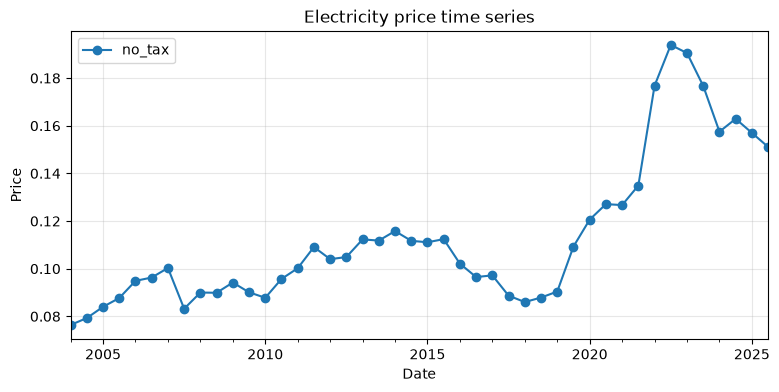

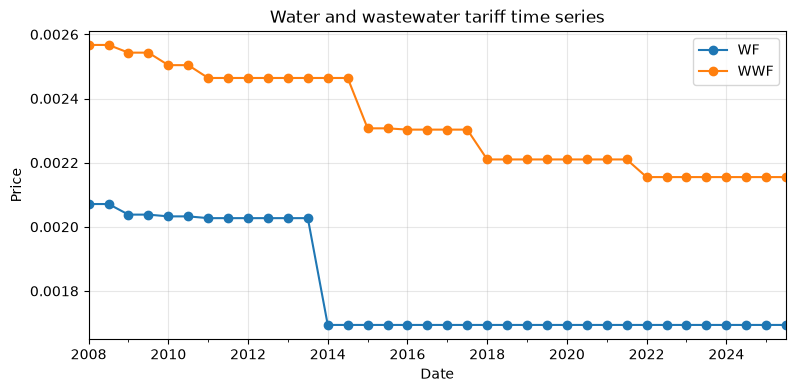

,Input group,Distribution,Range,Mode,Reason
0,Historical metals,triangular,observed min to observed max,historical mean,historical price series available
1,Electricity and water resource costs,triangular,20-year min to 20-year max,20-year mean,historical resource-cost variation available
2,Components without time series,uniform,importance-based,none,point estimate only


In [2]:
# Distribution assumptions and diagnostic helpers
# This cell documents the distribution choices used throughout the Monte Carlo model.
# It also provides small plotting utilities so that the historical input data can be
# inspected before deciding whether a distribution is reasonable.

DISTRIBUTION_POLICY = {
    "historical_time_series": "triangular: observed minimum, historical mean as mode, observed maximum",
    "point_estimate_only": "uniform: no empirical mode is available",
}

UNCERTAINTY_RANGE_BY_IMPORTANCE = {
    "high": {"min_share": 0.10, "relative_half_width": 0.25},
    "medium": {"min_share": 0.01, "relative_half_width": 0.20},
    "low": {"min_share": 0.00, "relative_half_width": 0.10},
}

# Historical uncertainty assumptions for Monte Carlo inputs.
# For these inputs, the Excel sheets provide historical summary statistics.
# The triangular distribution uses min and max as empirical bounds and the mean as mode.
HISTORICAL_DISTRIBUTIONS = {
    'metals': {'Steel': {'mean': 0.5831, 'std': 0.1404676025581025, 'variance': 0.01973114736842105, 'min': 0.37, 'max': 0.905, 'range': 0.535, 'c': 0.3983177570093457}, 
               'Copper': {'mean': 7.274755925478757, 'std': 1.453860395124267, 'variance': 2.113710048510888, 'min': 4.867897429653678, 'max': 9.946881947016749, 'range': 5.078984517363071, 'c': 0.4738857713775197}, 
               'Titanium': {'mean': 11.925, 'std': 1.018706610312673, 'variance': 1.037763157894737, 'min': 10.5, 'max': 15.0, 'range': 4.5, 'c': 0.3166666666666668}, 
               'Iridium': {'mean': 57171.74430158868, 'std': 56402.09775194612, 'variance': 3181196630.820086, 'min': 11217.17283387429, 'max': 163003.2337735307, 'range': 151786.0609396564, 'c': 0.30275883821758803}, 
               'Nickel': {'mean': 18.08900217153637, 'std': 6.413925515723414, 'variance': 41.13844052124786, 'min': 9.595179080988459, 'max': 37.13584189039519, 'range': 27.54066280940673, 'c': 0.30841026410035344}, 
               'Platinum': {'mean': 57171.74430158882, 'std': 56402.09775194625, 'variance': 3181196630.820101, 'min': 11217.17283387431, 'max': 163003.2337735311, 'range': 151786.0609396567, 'c': 0.302758838217588}},
    'resources': {'AWE_S1_resource_cost_20y': {'mean': 61316741.02431111, 'std': 16435798.17947772, 'variance': 270135461796523.16, 'min': 44855543.53819999, 'max': 98889531.23820001, 'range': 54033987.70000002, 'c': 0.3046452462014221}, 
                  'AWE_S2_resource_cost_20y': {'mean': 62305020.91764444, 'std': 16509099.359253697, 'variance': 272550361653710.84, 'min': 45838077.6182, 'max': 100647750.1182, 'range': 54809672.50000001, 'c': 0.3004386369840915}, 
                  'PEMWE_S1_resource_cost_20y': {'mean': 52747650.5617215, 'std': 14140943.38226515, 'variance': 199966279740428.53, 'min': 38585459.726880506, 'max': 85074161.12937808, 'range': 46488701.402497575, 'c': 0.3046372647027765}, 
                  'PEMWE_S2_resource_cost_20y': {'mean': 53597925.892899275, 'std': 14204014.922320748, 'variance': 201754039913510.47, 'min': 39430791.59683051, 'max': 86586860.26507808, 'range': 47156068.66824757, 'c': 0.30043077585066313}}
}

MODEL_DISTRIBUTIONS = {'AWE_material_cost': {'min': 704990.0967036329, 'mean': 928695.448652927, 'max': 1227688.2467915213, 'range': 522698.15008788847}, 
                       'AWE_CAPEX': {'min': 1113990.0967036327, 'mean': 1342695.4486529268, 'max': 1646688.2467915213, 'range': 532698.1500878886}, 
                       'AWE_S1_OPEX': {'min': 44950543.53819999, 'mean': 61417741.02431111, 'max': 98996531.23820001, 'range': 54045987.70000002}, 
                       'AWE_S2_OPEX': {'min': 45933077.6182, 'mean': 62406020.91764444, 'max': 100754750.1182, 'range': 54821672.50000001}, 
                       'AWE_S1_TCO': {'min': 46064532.634903625, 'mean': 62760435.97296403, 'max': 100643219.48499154, 'range': 54578686.85008791}, 
                       'AWE_S2_TCO': {'min': 47047066.71490363, 'mean': 63748715.866297364, 'max': 102401438.36499153, 'range': 55354371.6500879}}


def triangular_from_stats(stats):
    # scipy.stats.triang expects c=(mode-lower)/(upper-lower), loc=lower and scale=upper-lower.
    lower = float(stats['min'])
    upper = float(stats['max'])
    mode = float(stats.get('mean', lower + (upper - lower) / 2))
    if upper <= lower:
        return {'c': 0.5, 'loc': lower, 'scale': 0.0}
    c = (mode - lower) / (upper - lower)
    return {'c': float(max(0.0, min(1.0, c))), 'loc': lower, 'scale': upper - lower}


def uniform_from_bounds(lower, upper):
    # scipy.stats.uniform expects loc=lower and scale=upper-lower.
    lower = float(lower)
    upper = float(upper)
    if upper < lower:
        lower, upper = upper, lower
    return {'loc': lower, 'scale': upper - lower}


def uniform_from_stats(stats):
    return uniform_from_bounds(stats['min'], stats['max'])


def classify_cost_share(cost_share):
    if cost_share >= UNCERTAINTY_RANGE_BY_IMPORTANCE['high']['min_share']:
        return 'high'
    if cost_share >= UNCERTAINTY_RANGE_BY_IMPORTANCE['medium']['min_share']:
        return 'medium'
    return 'low'


def uniform_around_value(value, cost_share=None, relative_half_width=None):
    # The range is symmetric around the point estimate and clipped at zero.
    # If no explicit half-width is given, the cost share selects the range.
    value = float(value)
    if relative_half_width is None:
        importance = classify_cost_share(0.0 if cost_share is None else float(cost_share))
        relative_half_width = UNCERTAINTY_RANGE_BY_IMPORTANCE[importance]['relative_half_width']
    return uniform_from_bounds(max(0.0, value * (1.0 - relative_half_width)), value * (1.0 + relative_half_width))


def build_material_uncertainty_table(material_df, historical_materials=None):
    # This table is the audit trail for materials without historical time series.
    # It ranks inputs by their base cost and records why triangular or uniform was used.
    historical_materials = set(historical_materials or [])
    table = material_df.copy()
    table = table[table['Material and Component'].astype(str).str.lower() != 'total'].copy()
    table['Price'] = pd.to_numeric(table['Price'], errors='coerce')
    total = table['Price'].sum()
    table['Cost share'] = table['Price'] / total if total else 0.0
    table['Importance'] = table['Cost share'].apply(classify_cost_share)
    table['Relative half-width'] = table['Importance'].map(lambda x: UNCERTAINTY_RANGE_BY_IMPORTANCE[x]['relative_half_width'])
    table['Distribution'] = table['Material and Component'].apply(lambda x: 'triangular' if x in historical_materials else 'uniform')
    table['Reason'] = table.apply(
        lambda row: 'historical price series available'
        if row['Distribution'] == 'triangular'
        else f"no time series; {row['Importance']} cost impact, uniform +/-{row['Relative half-width']:.0%}",
        axis=1,
    )
    return table.sort_values('Price', ascending=False).reset_index(drop=True)


def plot_price_series(df, date_col='DATE', value_cols=None, title='Historical price series'):
    # Use this plot as the visual check for historical inputs.
    # Strong movement supports an empirical triangular range; very stable prices can
    # also be documented here before using a narrower range or a fixed value.
    value_cols = value_cols or [c for c in df.columns if c != date_col]
    ax = df.plot(x=date_col, y=value_cols, marker='o', figsize=(9, 4))
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.3)
    plt.show()
    return ax

# Plot the active historical inputs used for electricity and water.
# Electricity varies materially over time, so the resource-cost uncertainty uses a historical triangular range.
plot_price_series(pd.DataFrame(data_elc), value_cols=['no_tax'], title='Electricity price time series')

# Water tariffs are comparatively stable, but they are part of the total resource-cost history.
# The aggregated resource-cost range is still triangular because electricity dominates the variation.
plot_price_series(pd.DataFrame(water_data), value_cols=['WF', 'WWF'], title='Water and wastewater tariff time series')

distribution_assumptions = pd.DataFrame(
    [
        {'Input group': 'Historical metals', 'Distribution': 'triangular', 'Range': 'observed min to observed max', 'Mode': 'historical mean', 'Reason': 'historical price series available'},
        {'Input group': 'Electricity and water resource costs', 'Distribution': 'triangular', 'Range': '20-year min to 20-year max', 'Mode': '20-year mean', 'Reason': 'historical resource-cost variation available'},
        {'Input group': 'Components without time series', 'Distribution': 'uniform', 'Range': 'importance-based', 'Mode': 'none', 'Reason': 'point estimate only'},
    ]
)
distribution_assumptions


In [3]:
# Number of decimal places for Pandas output
pd.options.display.float_format = '{:20,.3f}'.format


In [5]:
# CAPEX - material cost for 5 MW AWE
# original CAPEX cell retained, but technology changed from PEMWE to AWE with updated AWE prices.

# Feed material data and corresponding price in
# Material type
material = ['Steel', 'Nickel', 'Copper', 'Zirfon Membrane', 'PTFE', 'HDPE', 'Power Cable', 'Data Cable',
            'KOH Tank', 'Gas-separator', 'Heat-exchanger', 'Water pump', 'Rectifier / power electronics',
            'Control unit', 'Housing']
# Set the corresponding amount for material type            
amount = [35511.808, 6721.452, 1855.36, 464, 3164.48, 304, 200, 2000,
          1, 2, 1, 4, 22, 1, 1]
# Set the unit for material type
material_unit = ['kg']*3
material_unit.extend(['m2'])
material_unit.extend(['kg']*2)
material_unit.extend(['m']*2)
material_unit.extend(['pcs']*7)

# Corresponding single price
# updated current AWE prices
price = [HISTORICAL_DISTRIBUTIONS['metals']['Steel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Nickel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Copper']['mean'],
         293.12, 83.1818181818182, 9.47368421052632, 47, 1.19,
         1195.82007741176, 2496.38117647059, 2735, 497, 15000, 13350.4, 4750]

single_price_unit = ['€/kg']*3
single_price_unit.extend(['€/m2'])
single_price_unit.extend(['€/kg']*2)
single_price_unit.extend(['€/m']*2)
single_price_unit.extend(['€/pcs']*7)

price_unit = ['€']*15

# Use pandas to organize the data and provide the names of the categories in the table
df = pd.DataFrame({'Material and Component' : material, 
                   'Amount':  amount,
                   'Unit' : material_unit,
                   'Single Price': price,
                   'Single Price Unit': single_price_unit,
                   'Price Unit': price_unit
                    })

# Calculate price based on amount and single price
df.insert(5, 'Price', [a*b for a, b in zip(df['Amount'], df['Single Price'])])

# calculate total price of every material
df = df.append({'Material and Component': 'Total', 'Price': df['Price'].sum(), 'Price Unit':'€'}, ignore_index=True)

# add name of row in table (Total)
as_list = df.index.tolist()
as_list[-1] = 'Total'
df.index = as_list

df.fillna('', inplace=True)

df.head(22)


# Rank materials and components by their cost contribution.
# This table explains the uncertainty ranges used below for point-estimate-only inputs.
# Historical materials keep triangular distributions; the remaining components use
# uniform ranges selected from their cost share.
material_uncertainty = build_material_uncertainty_table(df, historical_materials=['Steel', 'Nickel', 'Copper'])
#material_uncertainty[[
#    'Material and Component', 'Price', 'Cost share', 'Importance',
#    'Distribution', 'Relative half-width', 'Reason'
#]]
material_uncertainty


C:\Users\U501264\AppData\Local\Temp\ipykernel_8492\3625153085.py:55: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna('', inplace=True)


,Material and Component,Amount,Unit,Single Price,Single Price Unit,Price,Price Unit,Cost share,Importance,Relative half-width,Distribution,Reason
0,Rectifier / power electronics,22.000,pcs,"15,000.000",€/pcs,"330,000.000",€,0.355,high,0.250,uniform,"no time series; high cost impact, uniform +/-25%"
1,PTFE,"3,164.480",kg,83.182,€/kg,"263,227.200",€,0.283,high,0.250,uniform,"no time series; high cost impact, uniform +/-25%"
2,Zirfon Membrane,464.000,m2,293.120,€/m2,"136,007.680",€,0.146,high,0.250,uniform,"no time series; high cost impact, uniform +/-25%"
3,Nickel,"6,721.452",kg,18.089,€/kg,"121,584.360",€,0.131,high,0.250,triangular,historical price series available
4,Steel,"35,511.808",kg,0.583,€/kg,"20,706.935",€,0.022,medium,0.200,triangular,historical price series available
5,Copper,"1,855.360",kg,7.275,€/kg,"13,497.291",€,0.015,medium,0.200,triangular,historical price series available
6,Control unit,1.000,pcs,"13,350.400",€/pcs,"13,350.400",€,0.014,medium,0.200,uniform,"no time series; medium cost impact, uniform +/..."
7,Power Cable,200.000,m,47.000,€/m,"9,400.000",€,0.010,medium,0.200,uniform,"no time series; medium cost impact, uniform +/..."
8,Gas-separator,2.000,pcs,"2,496.381",€/pcs,"4,992.762",€,0.005,low,0.100,uniform,"no time series; low cost impact, uniform +/-10%"
9,Housing,1.000,pcs,"4,750.000",€/pcs,"4,750.000",€,0.005,low,0.100,uniform,"no time series; low cost impact, uniform +/-10%"


In [6]:
# CAPEX result (one figure)

# Extract total cost/price from the defined dataframe
material_cost = df['Price'].loc['Total']

# Feed needed data in
kwargs={
        'inflation_rate' : 0.01,                # Inflation rate
        'equity' : 0.25,                        # Equity
        'eq_rate_return' : 0.07,                # Equity rate of return
        'debt' : 0.75,                          # Debt
        'db_intrst_rate' : 0.045,               # Debt interest rate
        'material_full' : material_cost,        # Material cost - comes from the table above
        'per_m' : 0.208                         # Percentage of material cost (for labour cost)
        }

# Sort Labour and Investment cost out 
inv_cost = invest_cost(material=material_cost, ictg=0, **kwargs)        # ictg: Invest tax credit of grant

print(f"Investment Cost {inv_cost:.2f}")


Construction Labour Cost: 193168.65331980874
Investment Cost 1121864.10


Running 'CAPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 318.22outvar/s]
Simulation complete! Runtime: 0:00:00.104191
Calculating sensitivity indices for 'CAPEX'...
c:\Users\U501264\OneDrive - Scheer Group\Dokumente 1\Research\Papers\LCC-Comparison Paper 2026\LCC-tool\.venv\Lib\site-packages\monaco\dvars_sensitivity.py:97: UserWarning: Consider installing numba for better performance
  warn("Consider installing numba for better performance", UserWarning)
Calculating optimal hyperparameters Φ for 'CAPEX' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'CAPEX'">)

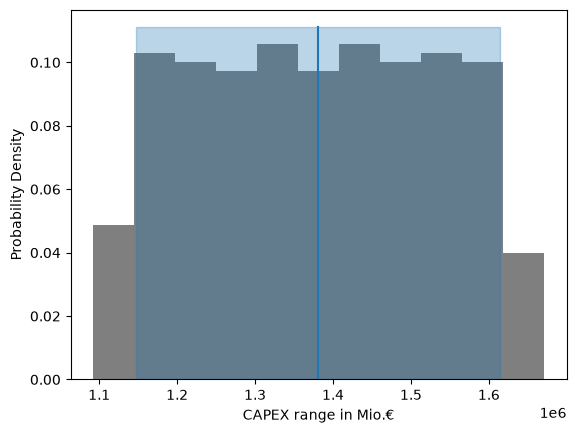

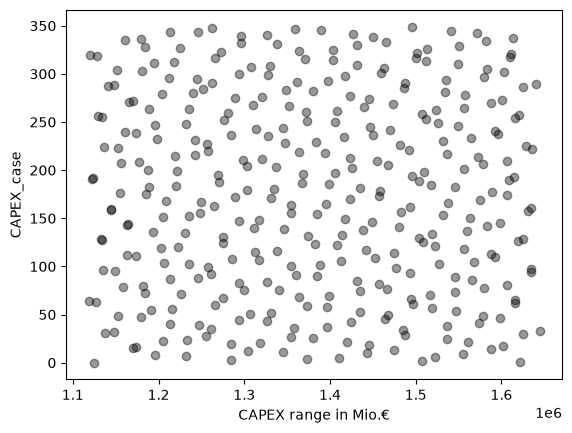

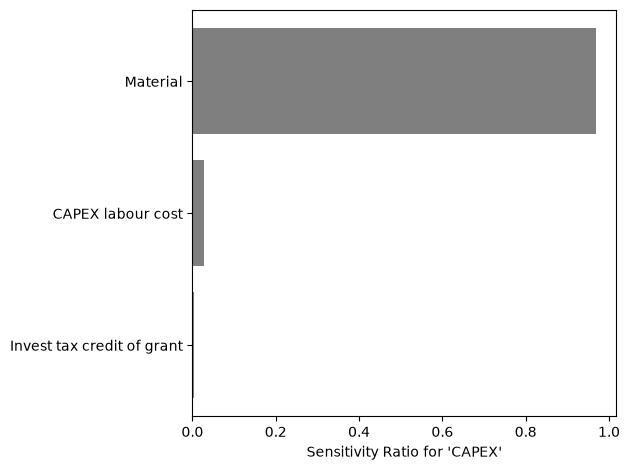

In [7]:
# Monaco CAPEX - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(material, capex_labour, ictg):
    """CAPEX only depends on material, labour and investment tax credit here.

    The original cell also sampled WACC-related variables. However, monte_capex()
    discounts with exponent **0, so those variables have no numerical effect on CAPEX.
    Keeping zero-effect inputs in Monaco's D-VARS sensitivity step can make the
    covariance matrix singular.
    """
    capex = material + capex_labour - ictg
    return (capex, )

# Rename the y-axis in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    material = case.invals['Material'].val
    capex_labour = case.invals['CAPEX labour cost'].val
    ictg = case.invals['Invest tax credit of grant'].val

    return (material, capex_labour, ictg)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, capex):
    case.addOutVal(name='CAPEX', val=capex)
    case.addOutVal(name='CAPEX_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='CAPEX', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# loc: represents the lower limit of the distribution
# scale: the interval length of the distribution
# e.g: using loc=0 and scale=1 we get a standard uniform distribution on [0, 1]
# By manually change loc and scale can manage the uncertainty of the cost
# Only variables that numerically affect CAPEX are included.
# WACC-related variables are excluded here because the CAPEX equation is not discounted at t=0.
sim.addInVar(name='Material', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_material_cost']))  # propagated from AWE material-cost inputs
sim.addInVar(name='CAPEX labour cost', dist=uniform, distkwargs={'loc': 410000, 'scale': 9000})
sim.addInVar(name='Invest tax credit of grant', dist=uniform, distkwargs=uniform_from_bounds(0, 1000))  # loc is lower bound, scale is range

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['CAPEX'].addVarStat('mean')
sim.outvars['CAPEX'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['CAPEX'])
plt.xlabel('CAPEX range in Mio.€')


# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['CAPEX'],
sim.outvars['CAPEX_case'])
# add Mio.€ in
plt.xlabel('CAPEX range in Mio.€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('CAPEX')
sim.outvars['CAPEX'].plotSensitivities()


Running 'Material Cost' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 15 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 320.22outvar/s]
Simulation complete! Runtime: 0:00:00.093347
Calculating sensitivity indices for 'Material Cost'...
c:\Users\U501264\OneDrive - Scheer Group\Dokumente 1\Research\Papers\LCC-Comparison Paper 2026\LCC-tool\.venv\Lib\site-packages\monaco\dvars_sensitivity.py:97: UserWarning: Consider installing numba for better performance
  warn("Consider installing numba for better performance", UserWarning)
Calculating optimal hyperparameters Φ for 'Material Cost' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'Material Cost'">)

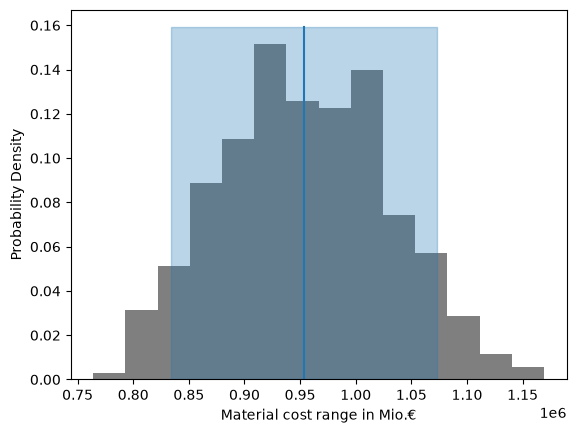

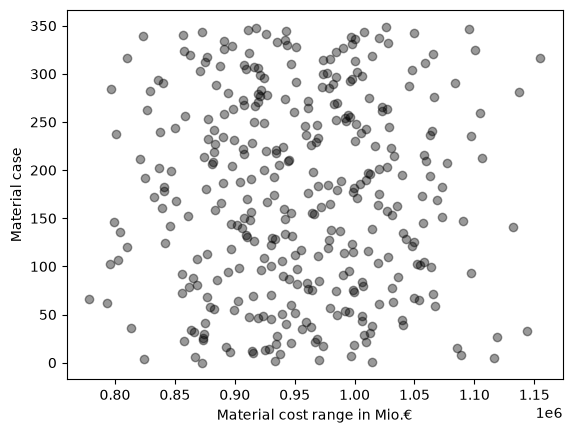

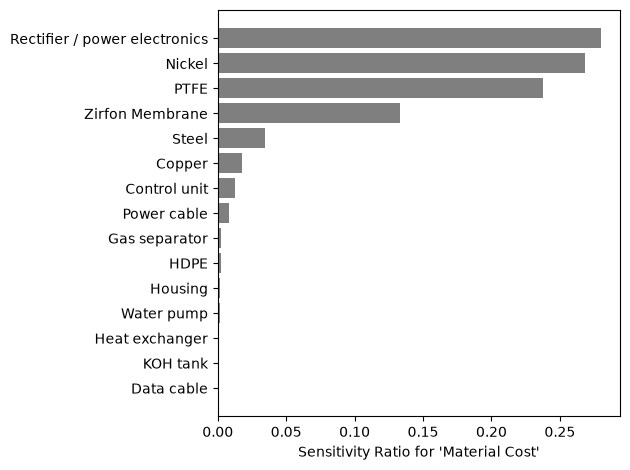

In [8]:
# Monaco material cost - Price range and sensitivity ratio
# original Monaco material-cost section retained; material variables changed from PEMWE to AWE.

# Function for running the monte carlo simulation
def run(steel, nickel, copper, zirfon_membrane, ptfe, hdpe,
        power_cable, data_cable, koh_tank, gas_separator, heat_exchanger,
        water_pump, rectifier_power_electronics, control_unit, housing):

    # run the material cost simulation
    material_cost = monte_awe_capex_5mw_current(steel=steel, nickel=nickel, copper=copper,
                                                zirfon_membrane=zirfon_membrane, ptfe=ptfe, hdpe=hdpe,
                                                power_cable=power_cable, data_cable=data_cable,
                                                koh_tank=koh_tank, gas_separator=gas_separator,
                                                heat_exchanger=heat_exchanger, water_pump=water_pump,
                                                rectifier_power_electronics=rectifier_power_electronics,
                                                control_unit=control_unit, housing=housing)
    return (material_cost, )

# Rename the y-axis in results
def preprocess(case):
    steel = case.invals['Steel'].val
    nickel = case.invals['Nickel'].val
    copper = case.invals['Copper'].val
    zirfon_membrane = case.invals['Zirfon Membrane'].val
    ptfe = case.invals['PTFE'].val
    hdpe = case.invals['HDPE'].val
    power_cable = case.invals['Power cable'].val
    data_cable = case.invals['Data cable'].val
    koh_tank = case.invals['KOH tank'].val
    gas_separator = case.invals['Gas separator'].val
    heat_exchanger = case.invals['Heat exchanger'].val
    water_pump = case.invals['Water pump'].val
    rectifier_power_electronics = case.invals['Rectifier / power electronics'].val
    control_unit = case.invals['Control unit'].val
    housing = case.invals['Housing'].val
    return (steel, nickel, copper, zirfon_membrane, ptfe, hdpe, power_cable, data_cable, koh_tank, gas_separator, heat_exchanger, water_pump, rectifier_power_electronics, control_unit, housing)

def postprocess(case, construction_cost):
    case.addOutVal(name='Material Cost', val=construction_cost)
    case.addOutVal(name='Material case', val=case.ncase)
    return None

fcns = {'run' : run, 'preprocess' : preprocess, 'postprocess': postprocess}
n_invests = 350
seed = 123456
sim = mc.Sim(name='Material Cost', ndraws=n_invests, fcns=fcns, seed=seed, samplemethod='sobol_random', singlethreaded=True, savecasedata=False, verbose=True, debug=True)

# Variables used in the simulation
# Historical metals use triangular distributions. Components without time series use
# importance-based uniform ranges from material_uncertainty.
sim.addInVar(name='Steel', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['metals']['Steel']))
sim.addInVar(name='Nickel', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['metals']['Nickel']))
sim.addInVar(name='Copper', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['metals']['Copper']))
sim.addInVar(name='Zirfon Membrane', dist=uniform, distkwargs=uniform_around_value(293.12, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Zirfon Membrane', 'Cost share'].iloc[0]))
sim.addInVar(name='PTFE', dist=uniform, distkwargs=uniform_around_value(83.1818181818182, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'PTFE', 'Cost share'].iloc[0]))
sim.addInVar(name='HDPE', dist=uniform, distkwargs=uniform_around_value(9.47368421052632, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'HDPE', 'Cost share'].iloc[0]))
sim.addInVar(name='Power cable', dist=uniform, distkwargs=uniform_around_value(47, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Power Cable', 'Cost share'].iloc[0]))
sim.addInVar(name='Data cable', dist=uniform, distkwargs=uniform_around_value(1.19, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Data Cable', 'Cost share'].iloc[0]))
sim.addInVar(name='KOH tank', dist=uniform, distkwargs=uniform_around_value(1195.82007741176, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'KOH Tank', 'Cost share'].iloc[0]))
sim.addInVar(name='Gas separator', dist=uniform, distkwargs=uniform_around_value(2496.38117647059, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Gas-separator', 'Cost share'].iloc[0]))
sim.addInVar(name='Heat exchanger', dist=uniform, distkwargs=uniform_around_value(2735, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Heat-exchanger', 'Cost share'].iloc[0]))
sim.addInVar(name='Water pump', dist=uniform, distkwargs=uniform_around_value(497, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Water pump', 'Cost share'].iloc[0]))
sim.addInVar(name='Rectifier / power electronics', dist=uniform, distkwargs=uniform_around_value(15000, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Rectifier / power electronics', 'Cost share'].iloc[0]))
sim.addInVar(name='Control unit', dist=uniform, distkwargs=uniform_around_value(13350.4, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Control unit', 'Cost share'].iloc[0]))
sim.addInVar(name='Housing', dist=uniform, distkwargs=uniform_around_value(4750, material_uncertainty.loc[material_uncertainty['Material and Component'] == 'Housing', 'Cost share'].iloc[0]))

sim.runSim()
sim.outvars['Material Cost'].addVarStat('mean')
sim.outvars['Material Cost'].addVarStat('percentile', {'p':[0.05, 0.95]})
mc.plot(sim.outvars['Material Cost'])
plt.xlabel('Material cost range in Mio.€')
mc.plot(sim.outvars['Material Cost'], sim.outvars['Material case'])
plt.xlabel('Material cost range in Mio.€')
sim.calcSensitivities('Material Cost')
sim.outvars['Material Cost'].plotSensitivities()


In [22]:
from SALib.sample import sobol
from SALib.analyze import sobol as sobol_analyze
import pandas as pd

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------

def triangular_from_stats(stats):
    """
    Construct triangular distribution from historical
    minimum, maximum and arithmetic mean.

    For a triangular distribution:

        mean = (lower + upper + mode) / 3

    Therefore:

        mode = 3*mean - lower - upper

    Returns SALib-compatible:
        [lower, upper, c]

    where:
        c = relative position of mode within [lower, upper]
    """

    lower = float(stats['min'])
    upper = float(stats['max'])
    mean = float(stats['mean'])

    if upper <= lower:
        raise ValueError(
            f"Invalid bounds: min={lower}, max={upper}"
        )
    mode = 3.0 * mean - lower - upper

    if not lower <= mode <= upper:
        raise ValueError(
            f"Historical statistics are inconsistent with a "
            f"triangular distribution: "
            f"min={lower:.4f}, mean={mean:.4f}, "
            f"max={upper:.4f}, inferred mode={mode:.4f}"
        )

    c = (mode - lower) / (upper - lower)

    return [
        lower,
        upper,
        float(c)
    ]

def lognormal_from_stats(stats):
    """
    Convert arithmetic mean and standard deviation
    to SALib lognormal parameters.

    SALib expects:
        [mean_ln, std_ln]

    where ln(X) ~ Normal(mean_ln, std_ln).
    """

    mean = float(stats['mean'])
    std = float(stats['std'])

    if mean <= 0:
        raise ValueError(
            "Lognormal distribution requires mean > 0."
        )

    if std <= 0:
        raise ValueError(
            "Lognormal distribution requires std > 0."
        )

    variance = std ** 2

    sigma_ln_squared = np.log(
        1.0 + variance / mean ** 2
    )

    sigma_ln = np.sqrt(sigma_ln_squared)

    mu_ln = (
        np.log(mean)
        - 0.5 * sigma_ln_squared
    )

    return [
        float(mu_ln),
        float(sigma_ln)
    ]


def salib_triangular_from_stats(stats):
    """
    Convert historical statistics into SALib triangular format:

        [lower, upper, c]
    """
    tri = triangular_from_stats(stats)

    lower = tri['loc']
    upper = tri['loc'] + tri['scale']
    c = tri['c']

    return [lower, upper, c]


def uniform_bounds(value, relative_half_width):
    """
    Convert nominal value +/- relative uncertainty
    into SALib uniform bounds.

    Example:
        value = 100
        relative_half_width = 0.25

        -> [75, 125]
    """
    value = float(value)
    relative_half_width = float(relative_half_width)

    lower = max(
        0.0,
        value * (1.0 - relative_half_width)
    )

    upper = value * (1.0 + relative_half_width)

    return [lower, upper]


def get_relative_half_width(material_name):
    return float(
        material_uncertainty.loc[
            material_uncertainty['Material and Component'] == material_name,
            'Relative half-width'
        ].iloc[0]
    )


def plot_sobol_results(problem, Si):

    results = pd.DataFrame({
        'Parameter': problem['names'],
        'S1': Si['S1'],
        'S1_conf': Si['S1_conf'],
        'ST': Si['ST'],
        'ST_conf': Si['ST_conf']
    })

    results['Interaction_effect'] = (
        results['ST'] - results['S1']
    )

    results['ST_percent'] = (
        results['ST'] * 100
    )


    # =====================================================
    # Figure 1: S1 and ST
    # =====================================================

    plot_data = results.sort_values(
        'ST',
        ascending=True
    )

    y_pos = np.arange(len(plot_data))
    bar_height = 0.35

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.barh(
        y_pos - bar_height / 2,
        plot_data['S1'],
        height=bar_height,
        xerr=plot_data['S1_conf'],
        capsize=3,
        label='S1'
    )

    ax.barh(
        y_pos + bar_height / 2,
        plot_data['ST'],
        height=bar_height,
        xerr=plot_data['ST_conf'],
        capsize=3,
        label='ST'
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data['Parameter'])

    ax.set_xlabel('Sobol sensitivity index')
    ax.set_title(
        'Sobol Sensitivity Analysis'
    )

    ax.legend()
    ax.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()


    # =====================================================
    # Figure 2: S1 versus ST
    # =====================================================

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(
        results['S1'],
        results['ST'],
        s=70
    )

    for _, row in results.iterrows():

        ax.annotate(
            row['Parameter'],
            (row['S1'], row['ST']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=8
        )

    max_value = max(
        results['S1'].max(),
        results['ST'].max()
    )

    ax.plot(
        [0, max_value],
        [0, max_value],
        linestyle='--'
    )

    ax.set_xlabel('First-order index (S1)')
    ax.set_ylabel('Total-order index (ST)')

    ax.set_title(
        'First-order vs Total-order Sensitivity'
    )

    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    # =====================================================
    # Figure 3: Percentage contribution
    # =====================================================

    percentage_data = results.sort_values(
        'ST_percent',
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.barh(
        percentage_data['Parameter'],
        percentage_data['ST_percent']
    )

    ax.set_xlabel(
        'Total-order sensitivity contribution (%)'
    )

    ax.set_title(
        'Input Contributions to Material-Cost Uncertainty'
    )

    ax.grid(
        axis='x',
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


    return results

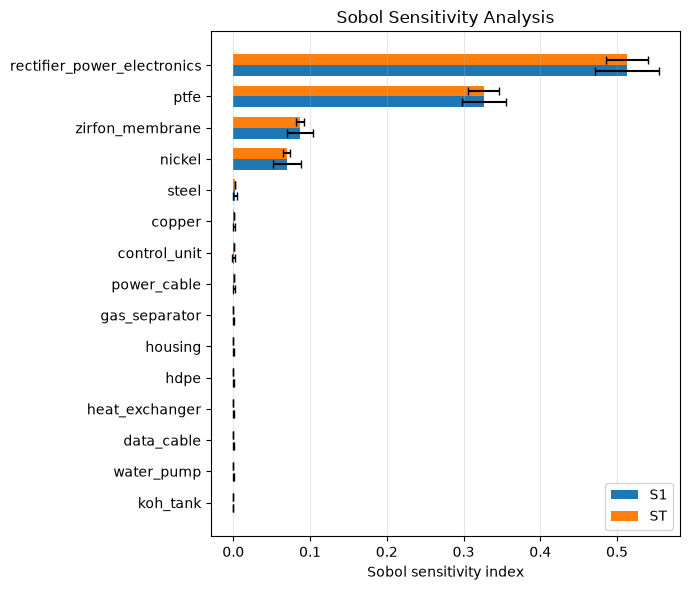

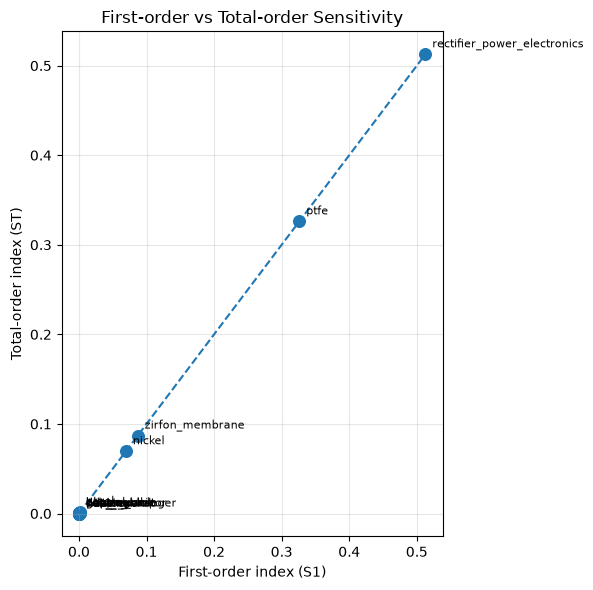

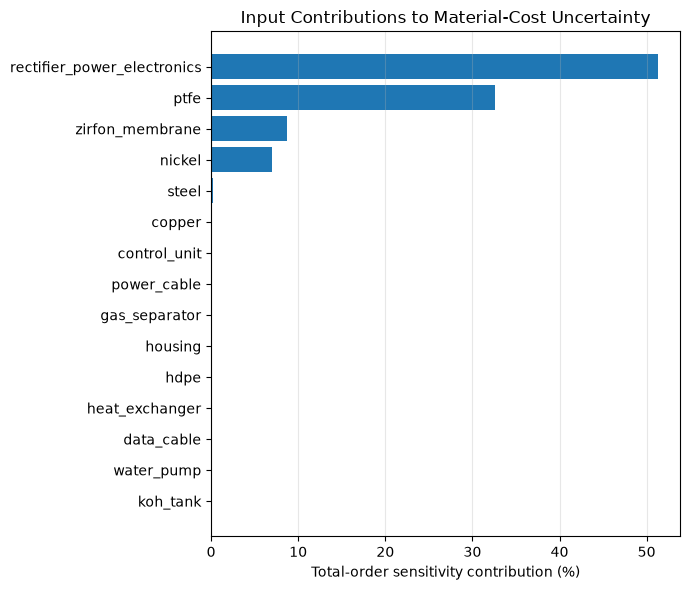

In [23]:
COMMON_HALF_WIDTH = 0.20

steel_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Steel',
            'Single Price'
        ].iloc[0]
nickel_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Nickel',
            'Single Price'
        ].iloc[0]
copper_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Copper',
            'Single Price'
        ].iloc[0]


problem_structural = {
    'num_vars': 15,

    'names': [
        'steel',
        'nickel',
        'copper',
        'zirfon_membrane',
        'ptfe',
        'hdpe',
        'power_cable',
        'data_cable',
        'koh_tank',
        'gas_separator',
        'heat_exchanger',
        'water_pump',
        'rectifier_power_electronics',
        'control_unit',
        'housing'
    ],

    'bounds': [
        uniform_bounds(steel_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(nickel_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(copper_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(293.12, COMMON_HALF_WIDTH),
        uniform_bounds(83.1818181818182, COMMON_HALF_WIDTH),
        uniform_bounds(9.47368421052632, COMMON_HALF_WIDTH),
        uniform_bounds(47, COMMON_HALF_WIDTH),
        uniform_bounds(1.19, COMMON_HALF_WIDTH),
        uniform_bounds(1195.82007741176, COMMON_HALF_WIDTH),
        uniform_bounds(2496.38117647059, COMMON_HALF_WIDTH),
        uniform_bounds(2735, COMMON_HALF_WIDTH),
        uniform_bounds(497, COMMON_HALF_WIDTH),
        uniform_bounds(15000, COMMON_HALF_WIDTH),
        uniform_bounds(13350.4, COMMON_HALF_WIDTH),
        uniform_bounds(4750, COMMON_HALF_WIDTH),
    ],

    'dists': ['unif'] * 15
}

# =========================================================
# Generate Sobol samples
# =========================================================

param_values = sobol.sample(
    problem_structural,
    N=2048,
    calc_second_order=False
)

# =========================================================
# Model coefficients
# Must correspond EXACTLY to problem['names']
# =========================================================

coefficients = np.array([
    35511.808,   # steel
    6721.452,    # nickel
    1855.36,     # copper
    464,         # zirfon_membrane
    3164.48,     # ptfe
    304,         # hdpe
    200,         # power_cable
    2000,        # data_cable
    1,           # koh_tank
    2,           # gas_separator
    1,           # heat_exchanger
    4,           # water_pump
    22,          # rectifier_power_electronics
    1,           # control_unit
    1            # housing
])


# =========================================================
# Evaluate all samples
# =========================================================

Y = param_values @ coefficients

# =========================================================
# Sobol analysis
# =========================================================

Si = sobol_analyze.analyze(
    problem_structural,
    Y,
    calc_second_order=False,
    print_to_console=False
)

sensitivity_results = pd.DataFrame({
    'Parameter': problem_structural['names'],
    'S1': Si['S1'],
    'S1_conf': Si['S1_conf'],
    'ST': Si['ST'],
    'ST_conf': Si['ST_conf']
})

sensitivity_results = sensitivity_results.sort_values(
    'ST',
    ascending=False
)

# Plot results
sensitivity_results = plot_sobol_results(
    problem_structural,
    Si
)


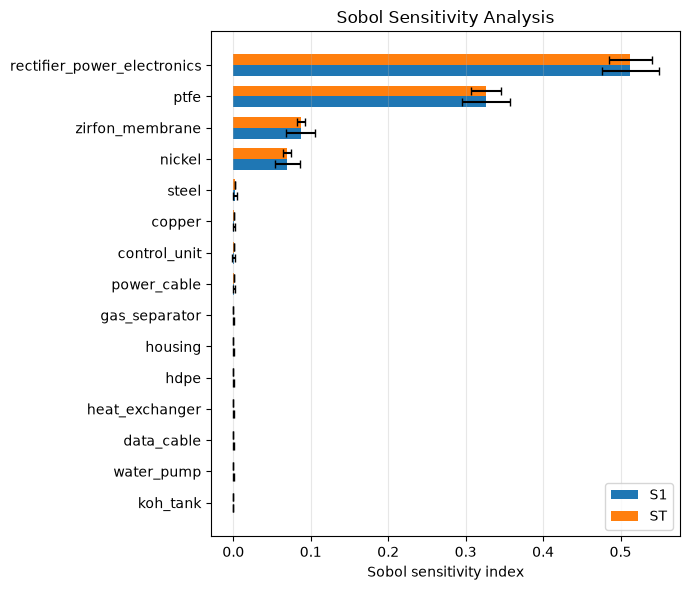

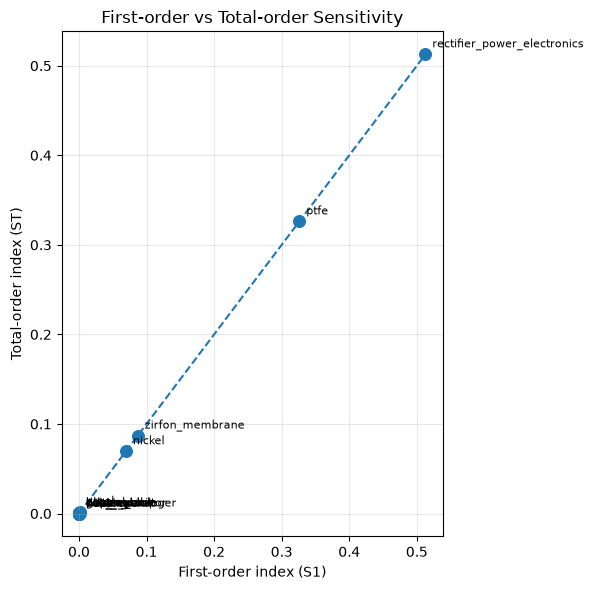

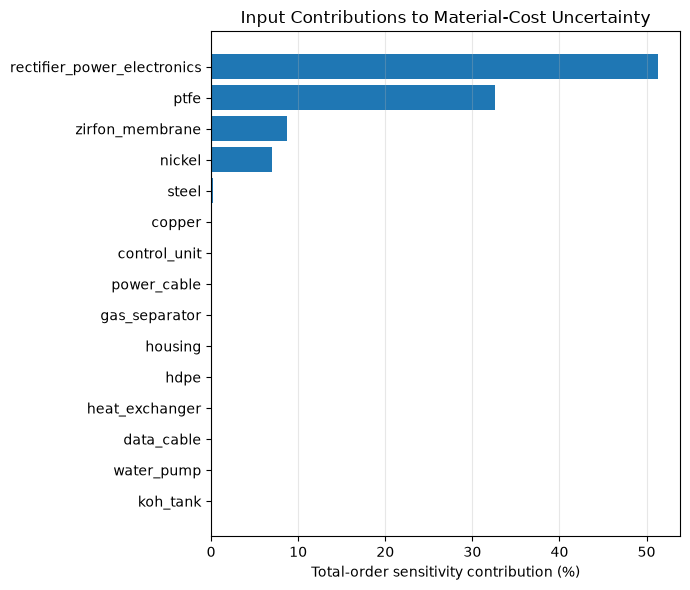

In [24]:
COMMON_HALF_WIDTH = 0.10

steel_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Steel',
            'Single Price'
        ].iloc[0]
nickel_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Nickel',
            'Single Price'
        ].iloc[0]
copper_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Copper',
            'Single Price'
        ].iloc[0]


problem_structural = {
    'num_vars': 15,

    'names': [
        'steel',
        'nickel',
        'copper',
        'zirfon_membrane',
        'ptfe',
        'hdpe',
        'power_cable',
        'data_cable',
        'koh_tank',
        'gas_separator',
        'heat_exchanger',
        'water_pump',
        'rectifier_power_electronics',
        'control_unit',
        'housing'
    ],

    'bounds': [
        uniform_bounds(steel_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(nickel_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(copper_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(293.12, COMMON_HALF_WIDTH),
        uniform_bounds(83.1818181818182, COMMON_HALF_WIDTH),
        uniform_bounds(9.47368421052632, COMMON_HALF_WIDTH),
        uniform_bounds(47, COMMON_HALF_WIDTH),
        uniform_bounds(1.19, COMMON_HALF_WIDTH),
        uniform_bounds(1195.82007741176, COMMON_HALF_WIDTH),
        uniform_bounds(2496.38117647059, COMMON_HALF_WIDTH),
        uniform_bounds(2735, COMMON_HALF_WIDTH),
        uniform_bounds(497, COMMON_HALF_WIDTH),
        uniform_bounds(15000, COMMON_HALF_WIDTH),
        uniform_bounds(13350.4, COMMON_HALF_WIDTH),
        uniform_bounds(4750, COMMON_HALF_WIDTH),
    ],

    'dists': ['unif'] * 15
}

# =========================================================
# Generate Sobol samples
# =========================================================

param_values = sobol.sample(
    problem_structural,
    N=2048,
    calc_second_order=False
)

# =========================================================
# Model coefficients
# Must correspond EXACTLY to problem['names']
# =========================================================

coefficients = np.array([
    35511.808,   # steel
    6721.452,    # nickel
    1855.36,     # copper
    464,         # zirfon_membrane
    3164.48,     # ptfe
    304,         # hdpe
    200,         # power_cable
    2000,        # data_cable
    1,           # koh_tank
    2,           # gas_separator
    1,           # heat_exchanger
    4,           # water_pump
    22,          # rectifier_power_electronics
    1,           # control_unit
    1            # housing
])


# =========================================================
# Evaluate all samples
# =========================================================

Y = param_values @ coefficients

# =========================================================
# Sobol analysis
# =========================================================

Si = sobol_analyze.analyze(
    problem_structural,
    Y,
    calc_second_order=False,
    print_to_console=False
)

sensitivity_results = pd.DataFrame({
    'Parameter': problem_structural['names'],
    'S1': Si['S1'],
    'S1_conf': Si['S1_conf'],
    'ST': Si['ST'],
    'ST_conf': Si['ST_conf']
})

sensitivity_results = sensitivity_results.sort_values(
    'ST',
    ascending=False
)

# Plot results
sensitivity_results = plot_sobol_results(
    problem_structural,
    Si
)

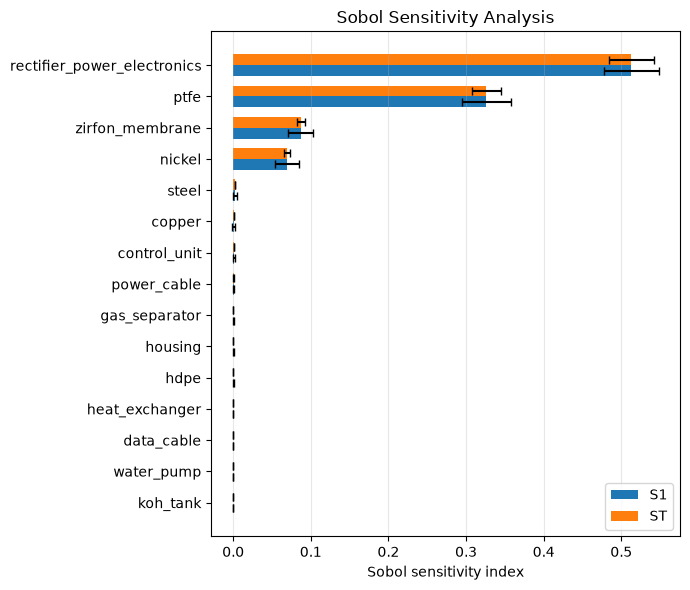

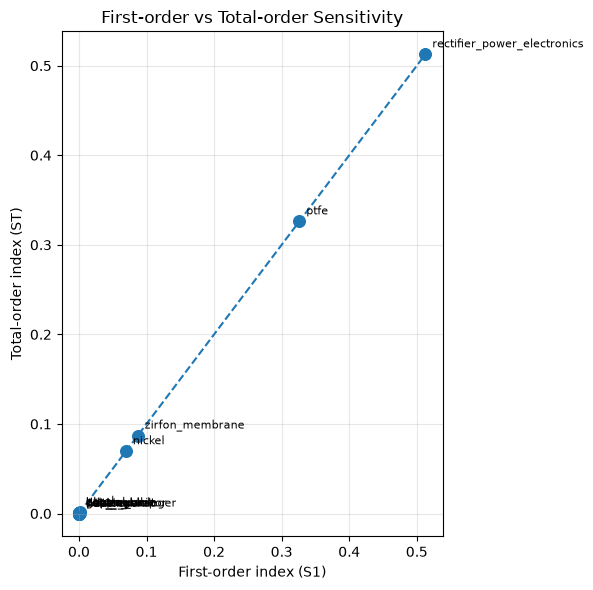

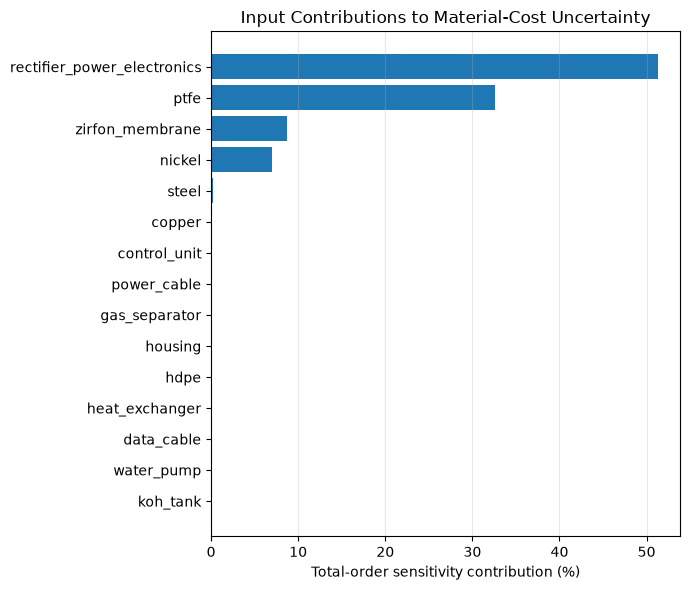

In [25]:
COMMON_HALF_WIDTH = 0.25

steel_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Steel',
            'Single Price'
        ].iloc[0]
nickel_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Nickel',
            'Single Price'
        ].iloc[0]
copper_baseline = material_uncertainty.loc[
            material_uncertainty['Material and Component'] == 'Copper',
            'Single Price'
        ].iloc[0]


problem_structural = {
    'num_vars': 15,

    'names': [
        'steel',
        'nickel',
        'copper',
        'zirfon_membrane',
        'ptfe',
        'hdpe',
        'power_cable',
        'data_cable',
        'koh_tank',
        'gas_separator',
        'heat_exchanger',
        'water_pump',
        'rectifier_power_electronics',
        'control_unit',
        'housing'
    ],

    'bounds': [
        uniform_bounds(steel_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(nickel_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(copper_baseline, COMMON_HALF_WIDTH),
        uniform_bounds(293.12, COMMON_HALF_WIDTH),
        uniform_bounds(83.1818181818182, COMMON_HALF_WIDTH),
        uniform_bounds(9.47368421052632, COMMON_HALF_WIDTH),
        uniform_bounds(47, COMMON_HALF_WIDTH),
        uniform_bounds(1.19, COMMON_HALF_WIDTH),
        uniform_bounds(1195.82007741176, COMMON_HALF_WIDTH),
        uniform_bounds(2496.38117647059, COMMON_HALF_WIDTH),
        uniform_bounds(2735, COMMON_HALF_WIDTH),
        uniform_bounds(497, COMMON_HALF_WIDTH),
        uniform_bounds(15000, COMMON_HALF_WIDTH),
        uniform_bounds(13350.4, COMMON_HALF_WIDTH),
        uniform_bounds(4750, COMMON_HALF_WIDTH),
    ],

    'dists': ['unif'] * 15
}

# =========================================================
# Generate Sobol samples
# =========================================================

param_values = sobol.sample(
    problem_structural,
    N=2048,
    calc_second_order=False
)

# =========================================================
# Model coefficients
# Must correspond EXACTLY to problem['names']
# =========================================================

coefficients = np.array([
    35511.808,   # steel
    6721.452,    # nickel
    1855.36,     # copper
    464,         # zirfon_membrane
    3164.48,     # ptfe
    304,         # hdpe
    200,         # power_cable
    2000,        # data_cable
    1,           # koh_tank
    2,           # gas_separator
    1,           # heat_exchanger
    4,           # water_pump
    22,          # rectifier_power_electronics
    1,           # control_unit
    1            # housing
])


# =========================================================
# Evaluate all samples
# =========================================================

Y = param_values @ coefficients

# =========================================================
# Sobol analysis
# =========================================================

Si = sobol_analyze.analyze(
    problem_structural,
    Y,
    calc_second_order=False,
    print_to_console=False
)

sensitivity_results = pd.DataFrame({
    'Parameter': problem_structural['names'],
    'S1': Si['S1'],
    'S1_conf': Si['S1_conf'],
    'ST': Si['ST'],
    'ST_conf': Si['ST_conf']
})

sensitivity_results = sensitivity_results.sort_values(
    'ST',
    ascending=False
)

# Plot results
sensitivity_results = plot_sobol_results(
    problem_structural,
    Si
)

### Uncertainty-informed sensitivity analysis

                                              ST              ST_conf
steel                                      0.002                0.000
nickel                                     0.070                0.004
copper                                     0.001                0.000
zirfon_membrane                            0.087                0.005
ptfe                                       0.326                0.017
hdpe                                       0.000                0.000
power_cable                                0.000                0.000
data_cable                                 0.000                0.000
koh_tank                                   0.000                0.000
gas_separator                              0.000                0.000
heat_exchanger                             0.000                0.000
water_pump                                 0.000                0.000
rectifier_power_electronics                0.513                0.030
control_unit        

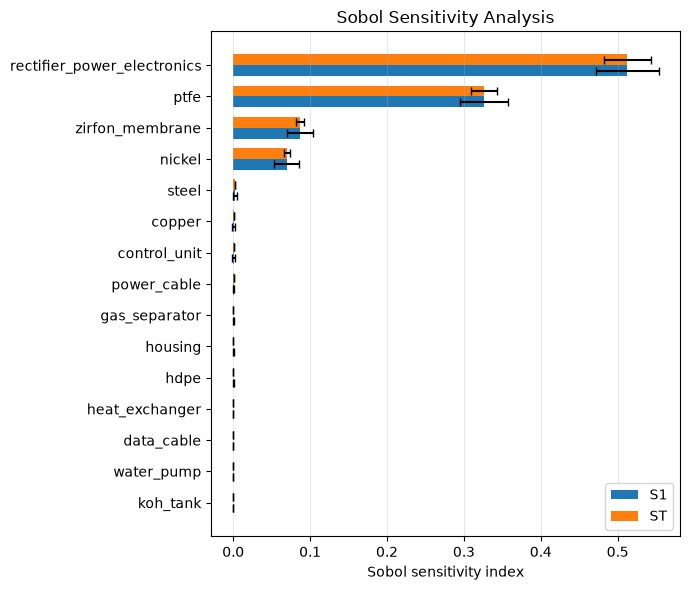

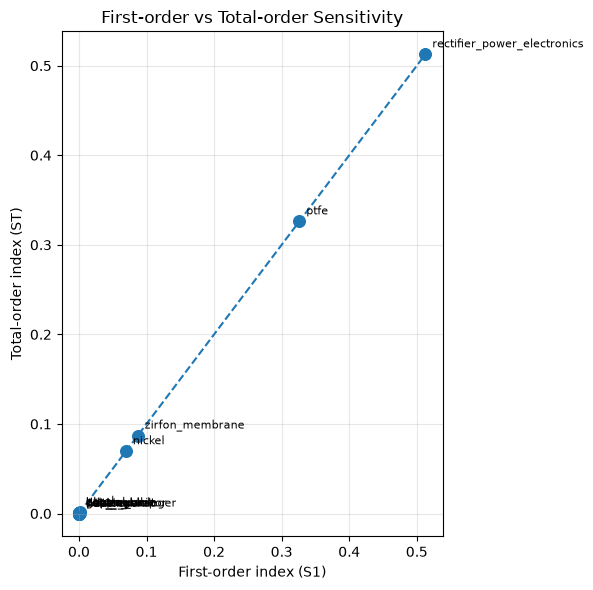

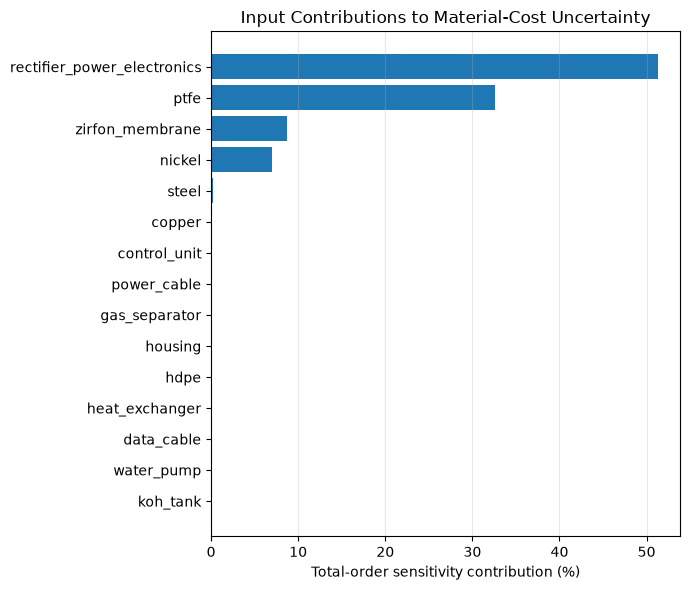

,Parameter,S1,S1_conf,ST,ST_conf,Interaction_effect,ST_percent
0,steel,0.002,0.003,0.002,0.000,0.000,0.202
1,nickel,0.070,0.016,0.070,0.004,0.000,6.960
2,copper,0.001,0.002,0.001,0.000,0.000,0.086
3,zirfon_membrane,0.087,0.017,0.087,0.005,0.000,8.709
4,ptfe,0.326,0.031,0.326,0.017,0.000,32.622
5,hdpe,0.000,0.000,0.000,0.000,-0.000,0.004
6,power_cable,0.000,0.001,0.000,0.000,-0.000,0.042
7,data_cable,0.000,0.000,0.000,0.000,0.000,0.003
8,koh_tank,0.000,0.000,0.000,0.000,-0.000,0.001
9,gas_separator,0.000,0.001,0.000,0.000,-0.000,0.012


In [26]:
problem_uncertainty = {
    'num_vars': 15,

    'names': ['steel','nickel','copper','zirfon_membrane','ptfe',
        'hdpe','power_cable','data_cable','koh_tank','gas_separator',
        'heat_exchanger','water_pump','rectifier_power_electronics','control_unit','housing'
    ],

    'bounds': [

        # Historical distributions
        triangular_from_stats(
            HISTORICAL_DISTRIBUTIONS['metals']['Steel']
        ),

        lognormal_from_stats(
            HISTORICAL_DISTRIBUTIONS['metals']['Nickel']
        ),

        triangular_from_stats(
            HISTORICAL_DISTRIBUTIONS['metals']['Copper']
        ),

        # Uniform distributions
        # Zirfon membrane: high importance -> +/-25%
        uniform_bounds(
            293.12,
            get_relative_half_width('Zirfon Membrane')
        ),

        # PTFE: high importance -> +/-25%
        uniform_bounds(
            83.1818181818182,
            get_relative_half_width('PTFE')
        ),

        # HDPE: low importance -> +/-10%
        uniform_bounds(
            9.47368421052632,
            get_relative_half_width('HDPE')
        ),

        # Power cable: medium importance -> +/-20%
        uniform_bounds(
            47,
            get_relative_half_width('Power Cable')
        ),

        # Data cable: low importance -> +/-10%
        uniform_bounds(
            1.19,
            get_relative_half_width('Data Cable')
        ),

        # KOH tank: low importance -> +/-10%
        uniform_bounds(
            1195.82007741176,
            get_relative_half_width('KOH Tank')
        ),

        # Gas separator: low importance -> +/-10%
        uniform_bounds(
            2496.38117647059,
            get_relative_half_width('Gas-separator')
        ),

        # Heat exchanger: low importance -> +/-10%
        uniform_bounds(
            2735,
            get_relative_half_width('Heat-exchanger')
        ),

        # Water pump: low importance -> +/-10%
        uniform_bounds(
            497,
            get_relative_half_width('Water pump')
        ),

        # Rectifier / power electronics: high importance -> +/-25%
        uniform_bounds(
            15000,
            get_relative_half_width(
                'Rectifier / power electronics'
            )
        ),

        # Control unit: medium importance -> +/-20%
        uniform_bounds(
            13350.4,
            get_relative_half_width('Control unit')
        ),

        # Housing: low importance -> +/-10%
        uniform_bounds(
            4750,
            get_relative_half_width('Housing')
        ),
    ],

    'dists': ['triang','lognorm','triang','unif','unif',
              'unif','unif','unif','unif','unif',
              'unif','unif','unif','unif','unif'
    ]
}

# =========================================================
# Model coefficients
# Must correspond EXACTLY to problem['names']
# =========================================================

coefficients = np.array([
    35511.808,   # steel
    6721.452,    # nickel
    1855.36,     # copper
    464,         # zirfon_membrane
    3164.48,     # ptfe
    304,         # hdpe
    200,         # power_cable
    2000,        # data_cable
    1,           # koh_tank
    2,           # gas_separator
    1,           # heat_exchanger
    4,           # water_pump
    22,          # rectifier_power_electronics
    1,           # control_unit
    1            # housing
])

# =========================================================
# 2. Vectorised material-cost calculation
# =========================================================

Y_uncertainty = param_values @ coefficients


# =========================================================
# 3. Sobol sensitivity analysis
# =========================================================

Si_uncertainty = sobol_analyze.analyze(
    problem_uncertainty,
    Y_uncertainty,
    calc_second_order=False,
    print_to_console=True
)

sensitivity_uncertainty = pd.DataFrame({
    'Parameter': problem_uncertainty['names'],
    'S1': Si_uncertainty['S1'],
    'S1_conf': Si_uncertainty['S1_conf'],
    'ST': Si_uncertainty['ST'],
    'ST_conf': Si_uncertainty['ST_conf']
})

sensitivity_uncertainty = (
    sensitivity_uncertainty
    .sort_values(
        'ST',
        ascending=False
    )
    .reset_index(drop=True)
)

plot_sobol_results(
    problem_uncertainty,
    Si_uncertainty
)

In [8]:
# Transport cost

# List all the cost indicators
waste_typs = ['Mixed scrap', 'Waste for recycling', 'Gypsum board, gypsum waste']
price = [0.23, 0.23, 0.1]
unit = ['€/kg']*3

df = pd.DataFrame({
                   'Waste type': waste_typs,
                   'Price': price,
                   'Unit': unit
                  })

df.head()


,Waste type,Price,Unit
0,Mixed scrap,0.230,€/kg
1,Waste for recycling,0.230,€/kg
2,"Gypsum board, gypsum waste",0.100,€/kg


In [9]:
# OPEX S1 and S2 - End of Life (EoL) cost - Salvage value (SV)
# original EoL table retained, but material list changed from PEMWE to AWE.

material = ['Steel', 'Nickel', 'Copper', 'Zirfon Membrane', 'PTFE', 'HDPE', 'Power Cable', 'Data Cable',
            'KOH Tank', 'Gas-separator', 'Heat-exchanger', 'Water pump', 'Rectifier / power electronics',
            'Control unit', 'Housing']
amount = [35511.808, 6721.452, 1855.36, 464, 3164.48, 304, 200, 2000,
          1, 2, 1, 4, 22, 1, 1]
unit = ['kg']*3 + ['m2'] + ['kg']*2 + ['m']*2 + ['pcs']*7
price = [HISTORICAL_DISTRIBUTIONS['metals']['Steel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Nickel']['mean'],
         HISTORICAL_DISTRIBUTIONS['metals']['Copper']['mean'],
         293.12, 83.1818181818182, 9.47368421052632, 47, 1.19,
         1195.82007741176, 2496.38117647059, 2735, 497, 15000, 13350.4, 4750]
price_unit = ['€']*15
recycle_ratio = [0.28, 0.35, 0.43, 0, 0, 0, 0.008, 0.008, 0.0002, 0.0002, 0.0002, 0.0002, 0.000013, 0.000013, 0.000043]
transport_price = [0.23]*15

# Use pandas to organize the data and provide the names of the categories in the table
df_eol = pd.DataFrame({'Material' : material, 
                   'Amount': amount,
                   'Unit' : unit,
                   'Single Price': price,
                   'Price Unit': price_unit,
                   'Recycle ratio': recycle_ratio,
                   'Transport/disposal cost': transport_price,
                    })

# Calculate total price and salvage value
df_eol.insert(5, 'Price', [a*b for a, b in zip(df_eol['Amount'], df_eol['Single Price'])])
df_eol.insert(8, 'Transport/disposal cost total', [a*b for a, b in zip(df_eol['Amount'], df_eol['Transport/disposal cost'])])
df_eol.insert(9, 'Salvage value', [a*b*c for a, b, c in zip(df_eol['Amount'], df_eol['Single Price'], df_eol['Recycle ratio'])])

df_eol = df_eol.append({'Material':'Total',
                        'Price': df_eol['Price'].sum(),
                        'Transport/disposal cost total': df_eol['Transport/disposal cost total'].sum(),
                        'Salvage value': df_eol['Salvage value'].sum()}, ignore_index=True)
as_list = df_eol.index.tolist()
as_list[-1] = 'Total'
df_eol.index = as_list
df_eol.fillna('', inplace=True)
df_eol.head(22)


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_36192\3679267804.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_eol.fillna('', inplace=True)



,Material,Amount,Unit,Single Price,Price Unit,Price,Recycle ratio,Transport/disposal cost,Transport/disposal cost total,Salvage value
0,Steel,"35,511.808",kg,0.583,€,"20,706.935",0.280,0.230,"8,167.716","5,797.942"
1,Nickel,"6,721.452",kg,18.089,€,"121,584.360",0.350,0.230,"1,545.934","42,554.526"
2,Copper,"1,855.360",kg,7.275,€,"13,497.291",0.430,0.230,426.733,"5,803.835"
3,Zirfon Membrane,464.000,m2,293.120,€,"136,007.680",0.000,0.230,106.720,0.000
4,PTFE,"3,164.480",kg,83.182,€,"263,227.200",0.000,0.230,727.830,0.000
5,HDPE,304.000,kg,9.474,€,"2,880.000",0.000,0.230,69.920,0.000
6,Power Cable,200.000,m,47.000,€,"9,400.000",0.008,0.230,46.000,75.200
7,Data Cable,"2,000.000",m,1.190,€,"2,380.000",0.008,0.230,460.000,19.040
8,KOH Tank,1.000,pcs,"1,195.820",€,"1,195.820",0.000,0.230,0.230,0.239
9,Gas-separator,2.000,pcs,"2,496.381",€,"4,992.762",0.000,0.230,0.460,0.999


In [10]:
# OPEX S1 and S2 - Deconstruction cost

# Feed data in function deconstruction_cost (utils.py)
# percentage of cc = percentage of construction cost (for calculate the deconstruction cost)
decon_cost = deconstruction_cost(construction_cost=material_cost, percentage_of_cc=0.06)
print(f"Deconstruction cost {decon_cost:.2f}")


Deconstruction cost 55721.73


In [11]:
 # OPEX S1 and S2 - EoL cost

# EoL cost is caculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25,                        # Equity
        'eq_rate_return': 0.07,                 # Equity rate of return
        'debt': 0.75,                           # Debt
        'db_intrst_rate': 0.045,                # Debt interest rate
        'construction_cost' : material_cost,    # Material cost - comes from table "CAPEX - material cost"
        'percentage_of_cc' : 0.06               # Percentage of material cost (for labour cost)
        }

transport_cost_disposal = df_eol['Transport/disposal cost total'].loc['Total']
salvage_value = df_eol['Salvage value'].loc['Total']

eol_cost, _ = end_of_life_cost(transport_cost_disposal=transport_cost_disposal, salvage_value=salvage_value, inflation_rate=0.01, **kwargs)
print(f"End of Life {eol_cost:.2f}")


End of Life 5847.94


Running 'End Of Life Cost' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 9 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 356.80outvar/s]
Simulation complete! Runtime: 0:00:00.069889
Calculating sensitivity indices for 'EoL Cost'...
Calculating optimal hyperparameters Φ for 'EoL Cost' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'EoL Cost'">)

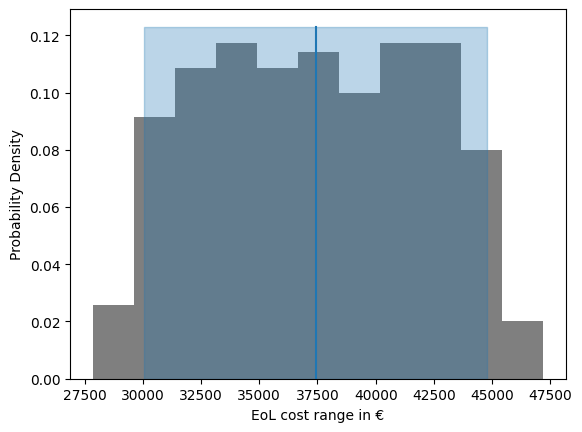

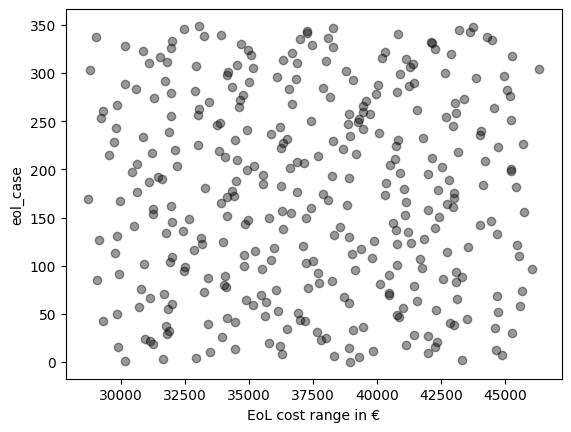

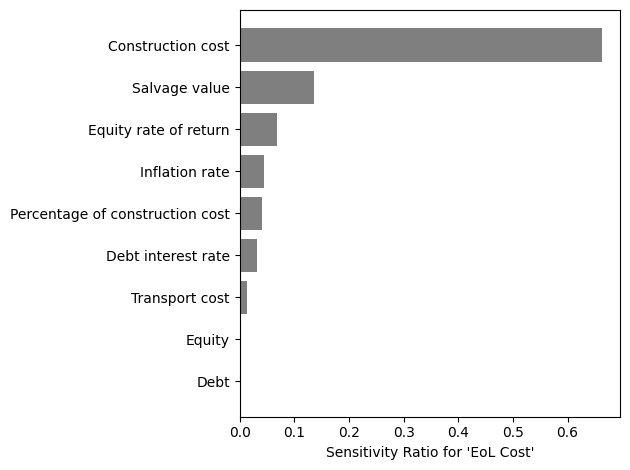

In [12]:
# Monaco EoL cost - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(transport_cost_disposal, salvage_value, construction_cost, percentage_of_cc, inflation_rate, equity, eq_rate_return, \
                debt, db_intrst_rate):
    
    # variables used within the end_of_life_cost function (utils.py)
    kwargs={
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        'construction_cost' : construction_cost,      
        'percentage_of_cc' : percentage_of_cc       
        }
    
    # run the capex simulation
    eol_cost, _ = end_of_life_cost(transport_cost_disposal=transport_cost_disposal, salvage_value=salvage_value, inflation_rate=inflation_rate, \
                                **kwargs)
    return (eol_cost, )

# Rename the y-axis in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    transport_cost_disposal = case.invals['Transport cost'].val
    salvage_value = case.invals['Salvage value'].val
    construction_cost = case.invals['Construction cost'].val
    percentage_of_cc = case.invals['Percentage of construction cost'].val
    inflation_rate = case.invals['Inflation rate'].val
    equity = case.invals['Equity'].val
    eq_rate_return = case.invals['Equity rate of return'].val
    debt = case.invals['Debt'].val
    db_intrst_rate = case.invals['Debt interest rate'].val

    return (transport_cost_disposal, salvage_value, construction_cost, percentage_of_cc, inflation_rate, equity, eq_rate_return, debt, db_intrst_rate)


# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, eol_cost):
    case.addOutVal(name='EoL Cost', val=eol_cost)
    case.addOutVal(name='eol_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='End Of Life Cost', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Transport cost', dist=uniform, distkwargs={'loc': 7000, 'scale': 500})
sim.addInVar(name='Salvage value', dist=uniform, distkwargs={'loc': 12000, 'scale': 5000})
sim.addInVar(name='Construction cost', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_CAPEX']))  # propagated CAPEX range
sim.addInVar(name='Percentage of construction cost', dist=uniform, distkwargs={'loc': 0.06, 'scale': 0.001})
sim.addInVar(name='Inflation rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.001})
sim.addInVar(name='Equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.01})
sim.addInVar(name='Equity rate of return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='Debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='Debt interest rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.001})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['EoL Cost'].addVarStat('mean')
sim.outvars['EoL Cost'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['EoL Cost'])
plt.xlabel('EoL cost range in €')


# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['EoL Cost'], 
        sim.outvars['eol_case'])
plt.xlabel('EoL cost range in €')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('EoL Cost')
sim.outvars['EoL Cost'].plotSensitivities()


#### Comments 
The present uncertainty ranges need to be reviewed because they are very unequal relative to their nominal values.
| Variable            | Current range |  Approx. relative width |
| ------------------- | ------------: | ----------------------: |
| Transport           |     7000–7500 |                  ~±3.4% |
| Salvage             |   12000–17000 | ~±17.2% around midpoint |
| % construction cost |   0.060–0.061 |                 ~±0.83% |
| Inflation           |   0.010–0.011 |                  ~±4.8% |
| Equity              |     0.15–0.16 |                  ~±3.2% |
| Equity return       |     0.05–0.06 |                  ~±9.1% |
| Debt                |     0.75–0.76 |                 ~±0.66% |
| Debt interest       |   0.045–0.046 |                  ~±1.1% |


In [ ]:
problem_eol_structural = {
    'num_vars': 9,
    'names':  [
        'transport_cost_disposal',
        'salvage_value',
        'construction_cost',
        'percentage_of_cc',
        'inflation_rate',
        'equity',
        'eq_rate_return',
        'debt',
        'db_intrst_rate'
    ],

    'bounds': [
        uniform_bounds(7250, 0.10),
        uniform_bounds(14500, 0.10),
        uniform_bounds(construction_cost_baseline, 0.10),
        uniform_bounds(0.06, 0.10),
        uniform_bounds(0.01, 0.10),
        uniform_bounds(0.15, 0.10),
        uniform_bounds(0.05, 0.10),
        uniform_bounds(0.75, 0.10),
        uniform_bounds(0.045, 0.10)
    ],

    'dists': ['unif'] * 9
}

In [13]:
# setup plt plot style
plt.style.use('seaborn-v0_8-ticks')


12:34:44 - cmdstanpy - INFO - Chain [1] start processing
12:34:44 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


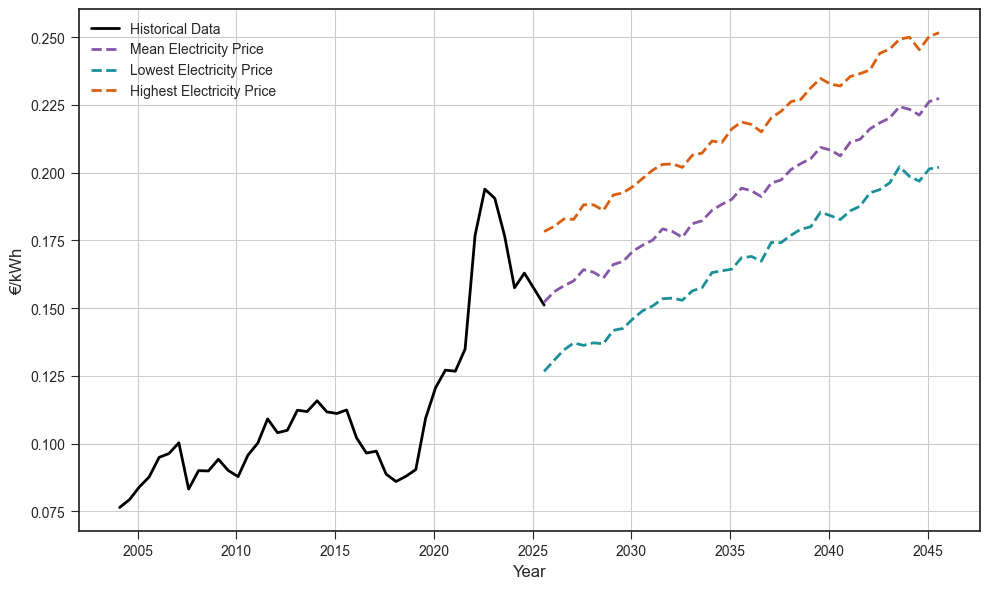

,S1_elc_price_lower,S1_elc_price_upper,S1_elc_price_mean,DATE
0,0.127,0.178,0.152,2025-07-31
1,0.131,0.180,0.156,2026-01-31
2,0.135,0.183,0.158,2026-07-31
3,0.137,0.183,0.160,2027-01-31
4,0.136,0.188,0.164,2027-07-31
5,0.137,0.188,0.163,2028-01-31
6,0.137,0.186,0.161,2028-07-31
7,0.142,0.192,0.166,2029-01-31
8,0.143,0.193,0.167,2029-07-31
9,0.146,0.195,0.171,2030-01-31


In [14]:
# Prophet - electricity (elc.) cost prediction in scenario 1 (S1)

# Insert historical data for elc. cost
df_elc = pd.DataFrame(data=data_elc)

# Run Prophet for elc. cost prediction (here only incl. "Beschaffung, Netzentgelt, Vertrieb"(BNV) + "Konzessionsabgabe"(KA))
# Use Pandas' iloc function to extract the yhat_lower(2), yhat_upper(3) and yhat(15) (mean) from the prophet result dataframe
prophet_NT_hat = prophet_fit_predict_elc(odf=df_elc, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of elc. cost needed to be considered, then... - 
# EEG-Umlage:                     prophet_EEGU_hat = prophet_fit_predict(odf=df_elc, var="EEGU", years=20, plot=False).iloc[: , [2, 3, 15]]
# KWKG-Umlage:                    prophet_KWKG_hat = prophet_fit_predict(odf=df_elc, var="KWKG", years=20, plot=False).iloc[: , [2, 3, 15]]
# Section 19 StromNEV surcharge:            prophet_NU_hat = prophet_fit_predict(odf=df_elc, var="19U", years=20, plot=False).iloc[: , [2, 3, 15]]
# Offshore-Netzumlage:            prophet_ONU_hat = prophet_fit_predict(odf=df_elc, var="ONU", years=20, plot=False).iloc[: , [2, 3, 15]]
# Umlage für abschaltbare Lasten: prophet_UAL_hat = prophet_fit_predict(odf=df_elc, var="UAL", years=20, plot=False).iloc[: , [2, 3, 15]]
# Electricity tax:                    prophet_SST_hat = prophet_fit_predict(odf=df_elc, var="SST", years=20, plot=False).iloc[: , [2, 3, 15]]


# Results of elc. cost prediction (plot + table)
# Apply an add reduce lambda function to the values of each row in prophet_BNV_hat and prophet_KA_hat
prophet_preds_elc = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
prophet_preds_elc['DATE'] = pd.date_range(start="2025-07-31", end="2045-07-31", freq="6ME")
prophet_preds_elc.rename(columns = {'yhat':'S1_elc_price_mean', 'yhat_lower':'S1_elc_price_lower',
                                    'yhat_upper':'S1_elc_price_upper'}, inplace = True)

# Sum all ground-truth data and predictions
df_elc['History'] = df_elc.sum(axis=1, numeric_only=True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc['DATE'], df_elc['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc['DATE'], prophet_preds_elc['S1_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc.head(50)


12:34:44 - cmdstanpy - INFO - Chain [1] start processing
12:34:45 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 3 Years...


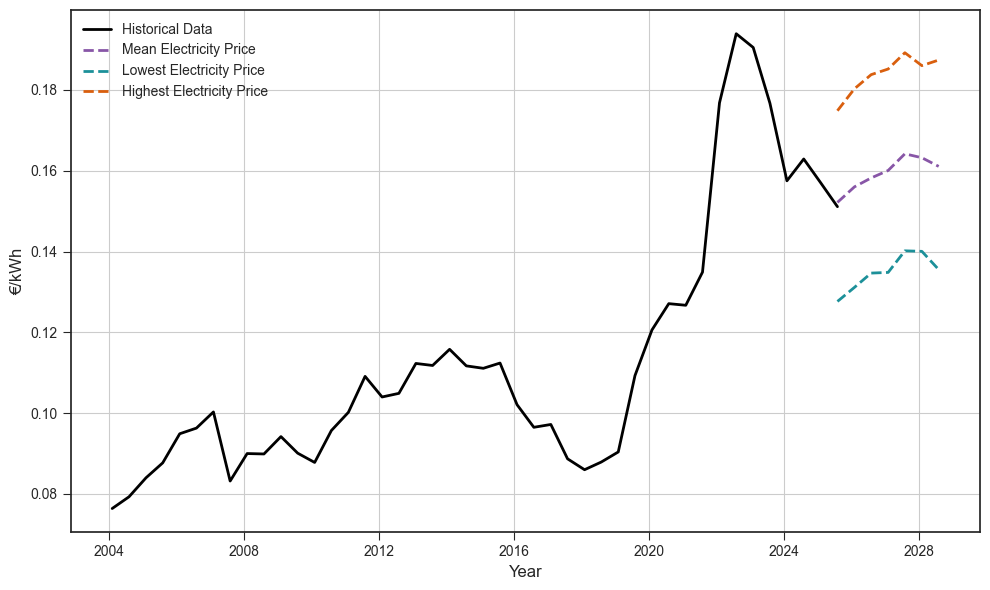

,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.128,0.175,0.152,2025-07-31
1,0.131,0.180,0.156,2026-01-31
2,0.135,0.184,0.158,2026-07-31
3,0.135,0.185,0.160,2027-01-31
4,0.140,0.189,0.164,2027-07-31
5,0.140,0.186,0.163,2028-01-31
6,0.136,0.187,0.161,2028-07-31


In [15]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.1

# For elctricity and water price prediction
df_elc_3y = pd.DataFrame(data=data_elc)

# Electricity cost prediction - 3 years with consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_3_years_after_war(odf=df_elc_3y, var="no_tax", years=3, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - 3 years with consideration of war and epidemic
prophet_preds_elc_3y = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_3y['History'] = df_elc_3y.sum(axis=1, numeric_only=True)
prophet_preds_elc_3y['DATE'] = pd.date_range(start="2025-07-31", end="2028-07-31", freq="6ME")
prophet_preds_elc_3y.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_3y['DATE'], df_elc_3y['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_3y['DATE'], prophet_preds_elc_3y['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))


# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_elc_3y.head(50)


12:34:45 - cmdstanpy - INFO - Chain [1] start processing
12:34:45 - cmdstanpy - INFO - Chain [1] done processing


Predicting no_tax for 20 Years...


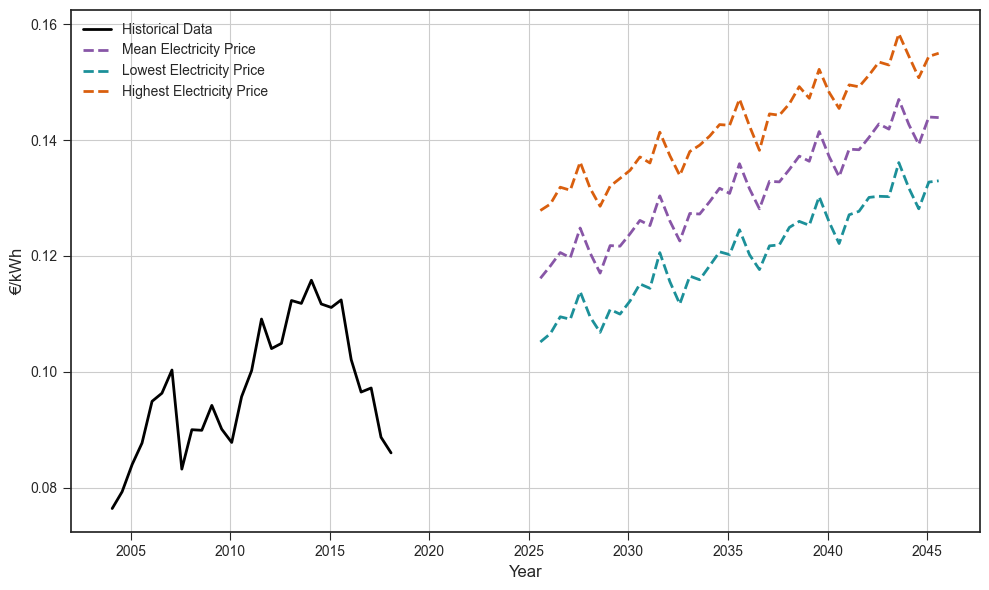

,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.105,0.128,0.116,2025-07-31
1,0.107,0.129,0.118,2026-01-31
2,0.109,0.132,0.121,2026-07-31
3,0.109,0.131,0.120,2027-01-31
4,0.114,0.136,0.125,2027-07-31
5,0.109,0.132,0.120,2028-01-31
6,0.107,0.129,0.117,2028-07-31
7,0.111,0.132,0.122,2029-01-31
8,0.110,0.133,0.122,2029-07-31
9,0.112,0.135,0.124,2030-01-31


In [16]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2

df_elc_rest = pd.DataFrame(data=data_nw_elc)

# Electricity cost prediction - without consideration of war and epidemic
prophet_NT_hat = prophet_fit_predict_elc_rest(odf=df_elc_rest, var="no_tax", years=20, plot=False).iloc[: , [2, 3, 15]]

# List and graphic of electricity cost prediction - after 3 years, the impact of war and epedemic will be gone, everything will be back to "normal" (cost trend before 2019)
prophet_preds_elc_nw = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_NT_hat])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df_elc_rest['History'] = df_elc_rest.sum(axis=1, numeric_only=True)
prophet_preds_elc_nw['DATE'] = pd.date_range(start="2025-07-31", end="2045-07-31", freq="6ME")
prophet_preds_elc_nw.rename(columns = {'yhat':'S2_elc_price_mean', 'yhat_lower':'S2_elc_price_lower',
                                    'yhat_upper':'S2_elc_price_upper'}, inplace = True)

# Creat Figure and subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the historical data
ax.plot(df_elc_rest['DATE'], df_elc_rest['History'], label='Historical Data', linestyle='-', linewidth=2, color='black')

# Draw the predictions
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_mean'], label='Mean Electricity Price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_lower'], label='Lowest Electricity Price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))
ax.plot(prophet_preds_elc_nw['DATE'], prophet_preds_elc_nw['S2_elc_price_upper'], label='Highest Electricity Price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))

# Set lables
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
#ax.set_title('Electricity Price Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()


#ax = df_elc_rest.plot(kind='line', x='DATE', y='History')
#prophet_preds_elc_nw.plot(ax = ax, x='DATE')

#plt.show()

prophet_preds_elc_nw.head(50)


In [17]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.1
# List of electricity price prediction - without 2023-2026

prophet_elc_rest=prophet_preds_elc_nw.head(50)
prophet_elc_rest.drop([0, 1, 2, 3, 4, 5, 6], axis=0, inplace=True)
print(prophet_elc_rest)


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_36192\1131735435.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_elc_rest.drop([0, 1, 2, 3, 4, 5, 6], axis=0, inplace=True)



     S2_elc_price_lower   S2_elc_price_upper    S2_elc_price_mean       DATE
7                 0.111                0.132                0.122 2029-01-31
8                 0.110                0.133                0.122 2029-07-31
9                 0.112                0.135                0.124 2030-01-31
10                0.115                0.137                0.126 2030-07-31
11                0.114                0.136                0.125 2031-01-31
12                0.121                0.141                0.130 2031-07-31
13                0.116                0.137                0.126 2032-01-31
14                0.112                0.134                0.123 2032-07-31
15                0.117                0.138                0.127 2033-01-31
16                0.116                0.139                0.127 2033-07-31
17                0.118                0.141                0.129 2034-01-31
18                0.121                0.143                0.132 2034-07-31

In [18]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 1.2.2
# Combine the 2 prediction together - list it

prophet_elc_price = pd.concat([prophet_preds_elc_3y, prophet_elc_rest], axis=0)
prophet_elc_price.head(50)


,S2_elc_price_lower,S2_elc_price_upper,S2_elc_price_mean,DATE
0,0.128,0.175,0.152,2025-07-31
1,0.131,0.180,0.156,2026-01-31
2,0.135,0.184,0.158,2026-07-31
3,0.135,0.185,0.160,2027-01-31
4,0.140,0.189,0.164,2027-07-31
5,0.140,0.186,0.163,2028-01-31
6,0.136,0.187,0.161,2028-07-31
7,0.111,0.132,0.122,2029-01-31
8,0.110,0.133,0.122,2029-07-31
9,0.112,0.135,0.124,2030-01-31


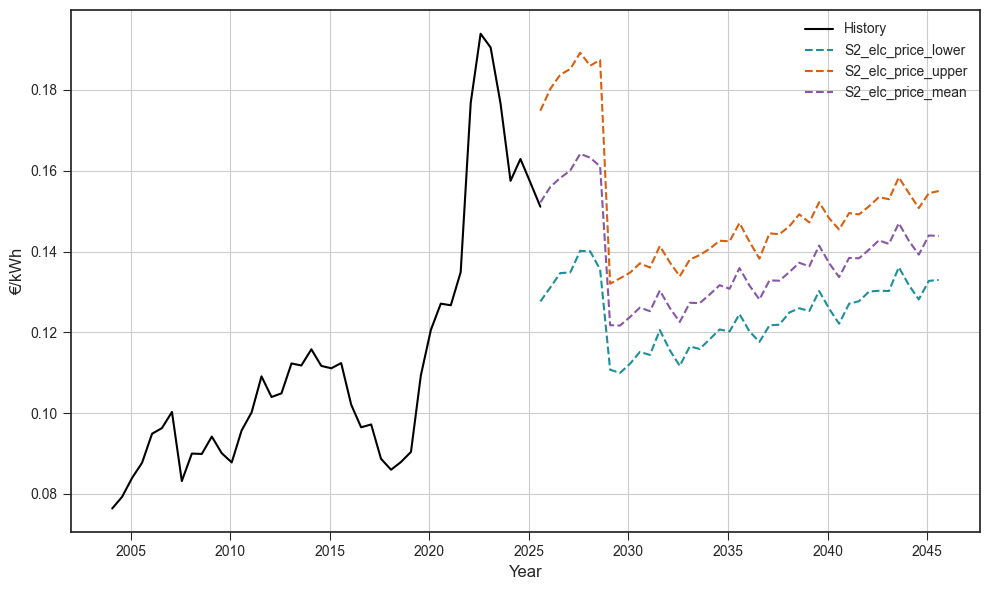

In [19]:
# Prophet - electricity (elc.) cost prediction in scenario 2 (S2) - Part 2
# Combine the 2 prediction together, plot the final S2 prediction

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred, lower_data, color=(28/255, 144/255, 153/255), linestyle='--', label='S2_elc_price_lower')
ax.plot(date_pred, upper_data, color=(217/255, 95/255, 14/255), linestyle='--', label='S2_elc_price_upper')
ax.plot(date_pred, pred_data, color=(136/255, 86/255, 167/255), linestyle='--', label='S2_elc_price_mean')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)
# If:
#   title is needed
# Then:
#   ax.set_title('S2', fontsize=14)
ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


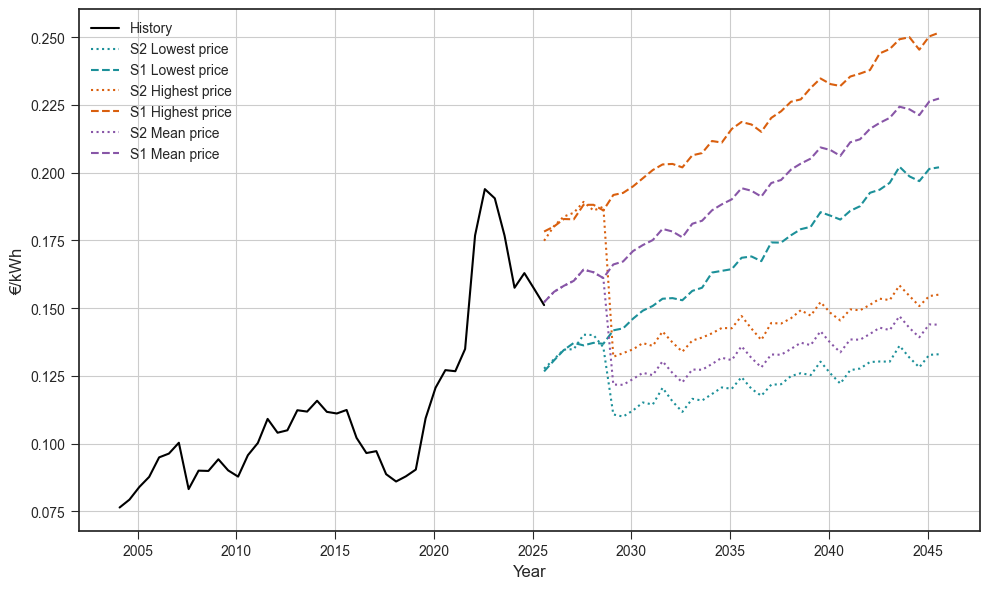

In [20]:
# Prophet - Combine the results of elc. cost in S1 and S2 together - For manuscript

# Set plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Feed data
date_history = df_elc_3y['DATE'].to_list()
data_history = df_elc_3y['History'].to_list()

lower_data = prophet_preds_elc_3y['S2_elc_price_lower'].to_list()
n_rest_elm = len(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()) - len(lower_data)
upper_data = prophet_preds_elc_3y['S2_elc_price_upper'].to_list()
pred_data = prophet_preds_elc_3y['S2_elc_price_mean'].to_list()

date_pred = prophet_preds_elc_nw['DATE'].to_list()
lower_data.extend(prophet_preds_elc_nw['S2_elc_price_lower'].to_list()[len(lower_data):])
upper_data.extend(prophet_preds_elc_nw['S2_elc_price_upper'].to_list()[len(upper_data):])
pred_data.extend(prophet_preds_elc_nw['S2_elc_price_mean'].to_list()[len(pred_data):])

# Set color
ax.plot(date_history, data_history, label='History', color='black')
ax.plot(date_pred, lower_data, color=(28/255, 144/255, 153/255), linestyle='dotted', label='S2 Lowest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_lower'].to_list(), color=(28/255, 144/255, 153/255), linestyle='--', label='S1 Lowest price')
ax.plot(date_pred, upper_data, color=(217/255, 95/255, 14/255), linestyle='dotted', label='S2 Highest price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_upper'].to_list(), color=(217/255, 95/255, 14/255), linestyle='--', label='S1 Highest price')
ax.plot(date_pred, pred_data, color=(136/255, 86/255, 167/255), linestyle='dotted', label='S2 Mean price')
ax.plot(date_pred, prophet_preds_elc['S1_elc_price_mean'].to_list(), color=(136/255, 86/255, 167/255), linestyle='--', label='S1 Mean price')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kWh', fontsize=12)

ax.legend(fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()


12:34:46 - cmdstanpy - INFO - Chain [1] start processing
12:34:46 - cmdstanpy - INFO - Chain [1] done processing
12:34:46 - cmdstanpy - INFO - Chain [1] start processing


Predicting WF for 20 Years...


12:34:47 - cmdstanpy - INFO - Chain [1] done processing


Predicting WWF for 20 Years...


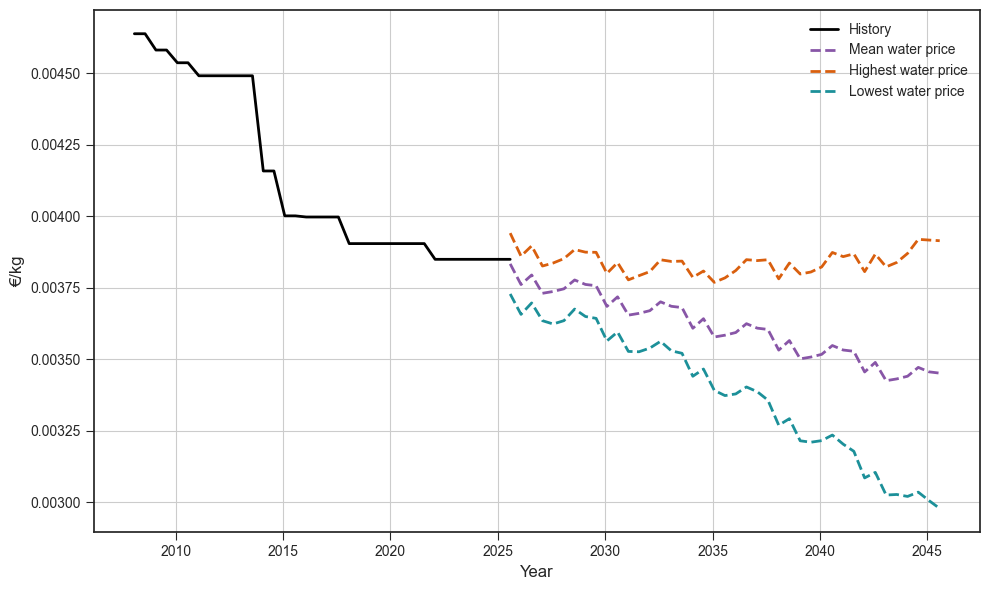

,wat_price_lower,wat_price_upper,wat_price_mean,DATE
0,0.004,0.004,0.004,2025-07-31
1,0.004,0.004,0.004,2026-01-31
2,0.004,0.004,0.004,2026-07-31
3,0.004,0.004,0.004,2027-01-31
4,0.004,0.004,0.004,2027-07-31
5,0.004,0.004,0.004,2028-01-31
6,0.004,0.004,0.004,2028-07-31
7,0.004,0.004,0.004,2029-01-31
8,0.004,0.004,0.004,2029-07-31
9,0.004,0.004,0.004,2030-01-31


In [21]:
# Prophet - water cost prediction

# Insert historical data for water
df = pd.DataFrame(water_data)

# Run package Prophet for water cost prediction (here only incl. "Water fee"(WF) and "Waste water fee"(WWF))
prophet_WF_hat = prophet_fit_predict_water(odf=df, var="WF", years=20, plot=False).iloc[: , [2, 3, 15]]
prophet_WWF_hat = prophet_fit_predict_water(odf=df, var="WWF", years=20, plot=False).iloc[: , [2, 3, 15]]

# - if followed element of water needed to be considered... - 
# Value added tax: prophet_VAT_hat = prophet_fit_predict_material(odf=df, var="VAT", years=20, plot=False).iloc[: , [2, 3, 15]]

# Results of water cost prediction (plot + table)
prophet_preds_wat = reduce(lambda a, b: a.add(b, fill_value=0), [prophet_WF_hat,
                                                                 prophet_WWF_hat 
                                                                 ])

# Set the interval for time-series prediction
# Ground-truth: previously given data
df['History'] = df.sum(axis=1, numeric_only=True)

# Sum all ground-truth data and predictions
prophet_preds_wat['DATE'] = pd.date_range(start="2025-07-31", end="2045-07-31", freq="6ME")
prophet_preds_wat.rename(columns = {'yhat':'wat_price_mean', 'yhat_lower':'wat_price_lower',
                                    'yhat_upper':'wat_price_upper'}, inplace = True)

# Create subplots
fig, ax = plt.subplots(figsize=(10, 6))

# Plot ground truth data
ax.plot(df['DATE'], df['History'], label='History', linestyle='-', linewidth=2, color='black')

# Plot predictions
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_mean'], label='Mean water price', linestyle='--', linewidth=2, color=(136/255, 86/255, 167/255))
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_upper'], label='Highest water price', linestyle='--', linewidth=2, color=(217/255, 95/255, 14/255))
ax.plot(prophet_preds_wat['DATE'], prophet_preds_wat['wat_price_lower'], label='Lowest water price', linestyle='--', linewidth=2, color=(28/255, 144/255, 153/255))

# Add labels for x and y-axis
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('€/kg', fontsize=12)

# Set x-axis ticks every 5 years starting from 2005
ax.xaxis.set_major_locator(mdates.YearLocator(base=5, month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

#ax.set_title('Water Cost Prediction', fontsize=14)
ax.legend(fontsize=10)

# Show plot
plt.grid(True)
plt.tight_layout()
plt.show()

# Show table
prophet_preds_wat.head(50)


In [22]:
# OPEX S1 - resource cost (water, electricity and KOH) for 5 MW AWE
# original OPEX section retained; AWE production, electricity, water and KOH inputs inserted.

h2_produced_amount = [489700]*41
h2_unit_elc = ['kg']*41
elc_used_amount = [52.8]*41
wat_used_amount = [10]*41
koh_used_amount = [0.0001]*41
koh_price = [0.603]*41
elc_price_unit = ['€/kWh']*41
wat_price_unit = ['€/kg']*41
koh_price_unit = ['€/kg']*41

# Provide the names of the categories in the table
df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit':  h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit':wat_price_unit,
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                   'Needed KOH': koh_used_amount,
                   'KOH Price': koh_price,
                   'KOH Price Unit': koh_price_unit,
                    })

cols_order = prophet_preds_wat.columns.to_list()
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)
df_global = pd.concat([df, n_prophet_preds_wat, prophet_preds_elc], axis=1)

# Provide the calculation method within the table
prefix = 'S1'
df_global[f'{prefix} Water Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_lower'])]
df_global[f'{prefix} Water Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_upper'])]
df_global[f'{prefix} Water Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_mean'])]
df_global[f'{prefix} Electricity Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_lower'])]
df_global[f'{prefix} Electricity Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_upper'])]
df_global[f'{prefix} Electricity Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_mean'])]
df_global[f'{prefix} KOH Price'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed KOH'], df_global['KOH Price'])]
df_global[f'{prefix} Total Resources Price Lower'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Lower'], df_global[f'{prefix} Water Price_Lower'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Higher'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Higher'], df_global[f'{prefix} Water Price_Higher'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Mean'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Mean'], df_global[f'{prefix} Water Price_Mean'], df_global[f'{prefix} KOH Price'])]

total_row = {f'{prefix} Electricity Price_Mean': df_global[f'{prefix} Electricity Price_Mean'].sum(),
             f'{prefix} Electricity Price_Higher': df_global[f'{prefix} Electricity Price_Higher'].sum(),
             f'{prefix} Electricity Price_Lower': df_global[f'{prefix} Electricity Price_Lower'].sum(),
             f'{prefix} Water Price_Mean': df_global[f'{prefix} Water Price_Mean'].sum(),
             f'{prefix} Water Price_Higher': df_global[f'{prefix} Water Price_Higher'].sum(),
             f'{prefix} Water Price_Lower': df_global[f'{prefix} Water Price_Lower'].sum(),
             f'{prefix} KOH Price': df_global[f'{prefix} KOH Price'].sum(),
             f'{prefix} Total Resources Price Lower': df_global[f'{prefix} Total Resources Price Lower'].sum(),
             f'{prefix} Total Resources Price Higher': df_global[f'{prefix} Total Resources Price Higher'].sum(),
             f'{prefix} Total Resources Price Mean': df_global[f'{prefix} Total Resources Price Mean'].sum()}
df_global = df_global.append(total_row, ignore_index=True)
as_list = df_global.index.tolist()
as_list[-1] = 'Total'
df_global.index = as_list
df_global.fillna('', inplace=True)

df_global.head()


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_36192\4093462632.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_global.fillna('', inplace=True)



,H2 Production,H2 Unit,Needed Water,Water Price Unit,Needed Electricity,Electricity Price Unit,Needed KOH,KOH Price,KOH Price Unit,wat_price_lower,...,S1 Water Price_Lower,S1 Water Price_Higher,S1 Water Price_Mean,S1 Electricity Price_Lower,S1 Electricity Price_Higher,S1 Electricity Price_Mean,S1 KOH Price,S1 Total Resources Price Lower,S1 Total Resources Price Higher,S1 Total Resources Price Mean
0,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,255.101","19,297.143","18,770.567","3,274,055.947","4,608,788.259","3,934,307.136",29.529,"3,292,340.577","4,628,114.930","3,953,107.233"
1,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,905.801","18,903.402","18,416.496","3,379,495.903","4,657,203.796","4,033,665.634",29.529,"3,397,431.233","4,676,136.727","4,052,111.658"
2,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,101.139","19,078.930","18,580.050","3,478,275.107","4,728,172.629","4,090,729.959",29.529,"3,496,405.774","4,747,281.088","4,109,339.539"
3,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,797.630","18,733.733","18,266.740","3,545,911.646","4,725,304.760","4,138,526.652",29.529,"3,563,738.805","4,744,068.022","4,156,822.920"
4,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,740.871","18,785.079","18,297.474","3,522,433.202","4,864,028.521","4,245,138.344",29.529,"3,540,203.602","4,882,843.129","4,263,465.347"


In [23]:
# OPEX S1 (with EoL cost) - Details
# S1_mean

# OPEX S1 (Mean) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_mean = df_global['S1 Total Resources Price Mean'].tolist()

op_cost_S1_mean = operation_cost(resource_cost=S1_resource_cost_mean, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_mean:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 79989891.46


In [24]:
# OPEX S1 (with EoL cost) - Details
# S1_higher

# OPEX S1 (High) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_high = df_global['S1 Total Resources Price Higher'].tolist()

op_cost_S1_high = operation_cost(resource_cost=S1_resource_cost_high, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_high:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 90401884.64


In [25]:
# OPEX S1 (with EoL cost) - Details
# S1_lower

# OPEX S1 (Low) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S1_resource_cost_low = df_global['S1 Total Resources Price Lower'].tolist()

op_cost_S1_low = operation_cost(resource_cost=S1_resource_cost_low, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S1_low:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 69675173.71


Running 'OPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 400.18outvar/s]
Simulation complete! Runtime: 0:00:00.044138
Calculating sensitivity indices for 'OPEX_S1'...
Calculating optimal hyperparameters Φ for 'OPEX_S1' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'OPEX_S1'">)

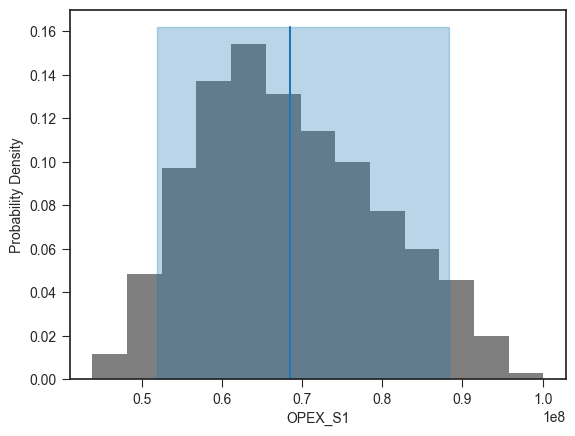

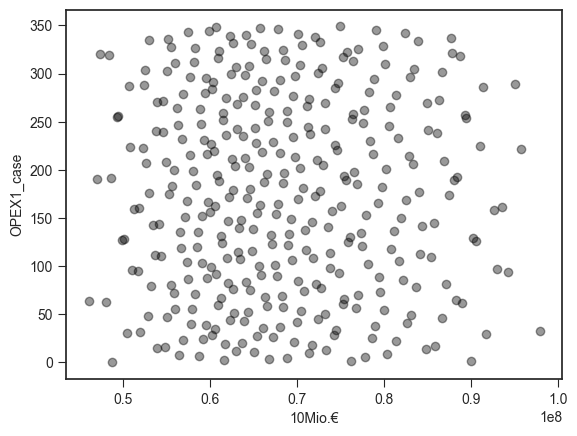

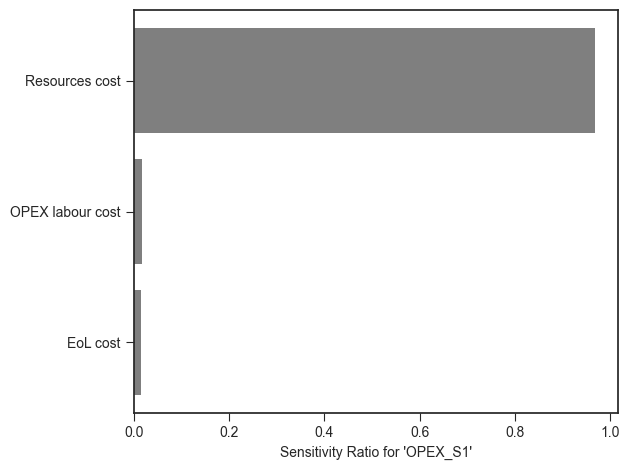

In [26]:
# Monaco OPEX S1 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(op_cost, op_labour, eol_cost):

    # run the opex simulation
    opr_cost = monte_opex(op_cost=op_cost, op_labour=op_labour, eol_cost=eol_cost)
    return (opr_cost, )

# Rename the y-axis in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    op_cost = case.invals['Resources cost'].val
    op_labour = case.invals['OPEX labour cost'].val
    eol_cost = case.invals['EoL cost'].val

    return (op_cost, op_labour, eol_cost)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, opr_cost):
    case.addOutVal(name='OPEX_S1', val=opr_cost)
    case.addOutVal(name='OPEX1_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='OPEX', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# loc: represents the lower limit of the distribution
# scale: the interval length of the distribution
# e.g: using loc=0 and scale=1 we get a standard uniform distribution on [0, 1]
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Resources cost', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['resources']['AWE_S1_resource_cost_20y']))
sim.addInVar(name='OPEX labour cost', dist=uniform, distkwargs={'loc': 45000, 'scale': 10000})
sim.addInVar(name='EoL cost', dist=uniform, distkwargs={'loc': 50000, 'scale': 2000})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# statistics for the dice sum
sim.outvars['OPEX_S1'].addVarStat('mean')
sim.outvars['OPEX_S1'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['OPEX_S1'])
# Creates a scatter plot of the sum vs the roll
# number, showing randomness
mc.plot(sim.outvars['OPEX_S1'],
sim.outvars['OPEX1_case'])

# add Mio.€ in
plt.xlabel('10Mio.€')

# Calculate the sensitivity of the dice sum to
# each of the input variables
sim.calcSensitivities('OPEX_S1')
sim.outvars['OPEX_S1'].plotSensitivities()


In [27]:
# OPEX S2 - resource cost (water, electricity and KOH) for 5 MW AWE
# original OPEX section retained; AWE production, electricity, water and KOH inputs inserted.

h2_produced_amount = [489700]*41
h2_unit_elc = ['kg']*41
elc_used_amount = [52.8]*41
wat_used_amount = [10]*41
koh_used_amount = [0.0001]*41
koh_price = [0.603]*41
elc_price_unit = ['€/kWh']*41
wat_price_unit = ['€/kg']*41
koh_price_unit = ['€/kg']*41

# Provide the names of the categories in the table
df = pd.DataFrame({'H2 Production' : h2_produced_amount,
                   'H2 Unit':  h2_unit_elc,
                   'Needed Water': wat_used_amount,
                   'Water Price Unit':wat_price_unit,
                   'Needed Electricity': elc_used_amount,
                   'Electricity Price Unit': elc_price_unit,
                   'Needed KOH': koh_used_amount,
                   'KOH Price': koh_price,
                   'KOH Price Unit': koh_price_unit,
                    })

cols_order = prophet_preds_wat.columns.to_list()
n_prophet_preds_wat = prophet_preds_wat.drop(prophet_preds_wat.columns[cols_order.index('DATE')], axis=1)
df_global = pd.concat([df, n_prophet_preds_wat, prophet_elc_price], axis=1)

# Provide the calculation method within the table
prefix = 'S2'
df_global[f'{prefix} Water Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_lower'])]
df_global[f'{prefix} Water Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_upper'])]
df_global[f'{prefix} Water Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Water'], df_global['wat_price_mean'])]
df_global[f'{prefix} Electricity Price_Lower'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_lower'])]
df_global[f'{prefix} Electricity Price_Higher'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_upper'])]
df_global[f'{prefix} Electricity Price_Mean'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed Electricity'], df_global[f'{prefix}_elc_price_mean'])]
df_global[f'{prefix} KOH Price'] = [a*b*c for a, b, c in zip(df_global['H2 Production'], df_global['Needed KOH'], df_global['KOH Price'])]
df_global[f'{prefix} Total Resources Price Lower'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Lower'], df_global[f'{prefix} Water Price_Lower'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Higher'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Higher'], df_global[f'{prefix} Water Price_Higher'], df_global[f'{prefix} KOH Price'])]
df_global[f'{prefix} Total Resources Price Mean'] = [a+b+c for a, b, c in zip(df_global[f'{prefix} Electricity Price_Mean'], df_global[f'{prefix} Water Price_Mean'], df_global[f'{prefix} KOH Price'])]

total_row = {f'{prefix} Electricity Price_Mean': df_global[f'{prefix} Electricity Price_Mean'].sum(),
             f'{prefix} Electricity Price_Higher': df_global[f'{prefix} Electricity Price_Higher'].sum(),
             f'{prefix} Electricity Price_Lower': df_global[f'{prefix} Electricity Price_Lower'].sum(),
             f'{prefix} Water Price_Mean': df_global[f'{prefix} Water Price_Mean'].sum(),
             f'{prefix} Water Price_Higher': df_global[f'{prefix} Water Price_Higher'].sum(),
             f'{prefix} Water Price_Lower': df_global[f'{prefix} Water Price_Lower'].sum(),
             f'{prefix} KOH Price': df_global[f'{prefix} KOH Price'].sum(),
             f'{prefix} Total Resources Price Lower': df_global[f'{prefix} Total Resources Price Lower'].sum(),
             f'{prefix} Total Resources Price Higher': df_global[f'{prefix} Total Resources Price Higher'].sum(),
             f'{prefix} Total Resources Price Mean': df_global[f'{prefix} Total Resources Price Mean'].sum()}
df_global = df_global.append(total_row, ignore_index=True)
as_list = df_global.index.tolist()
as_list[-1] = 'Total'
df_global.index = as_list
df_global.fillna('', inplace=True)

df_global.head()


WARNING - (py.warnings._showwarnmsg) - C:\Users\AnnKa\AppData\Local\Temp\ipykernel_36192\4197644471.py:57: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_global.fillna('', inplace=True)



,H2 Production,H2 Unit,Needed Water,Water Price Unit,Needed Electricity,Electricity Price Unit,Needed KOH,KOH Price,KOH Price Unit,wat_price_lower,...,S2 Water Price_Lower,S2 Water Price_Higher,S2 Water Price_Mean,S2 Electricity Price_Lower,S2 Electricity Price_Higher,S2 Electricity Price_Mean,S2 KOH Price,S2 Total Resources Price Lower,S2 Total Resources Price Higher,S2 Total Resources Price Mean
0,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,255.101","19,297.143","18,770.567","3,300,464.640","4,520,937.899","3,934,307.136",29.529,"3,318,749.270","4,540,264.571","3,953,107.233"
1,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,905.801","18,903.402","18,416.496","3,390,375.839","4,661,245.224","4,033,665.634",29.529,"3,408,311.169","4,680,178.154","4,052,111.658"
2,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"18,101.139","19,078.930","18,580.050","3,481,902.644","4,751,695.744","4,090,729.959",29.529,"3,500,033.312","4,770,804.203","4,109,339.539"
3,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,797.630","18,733.733","18,266.740","3,486,176.284","4,787,734.417","4,138,526.652",29.529,"3,504,003.442","4,806,497.679","4,156,822.920"
4,"489,700.000",kg,10.000,€/kg,52.800,€/kWh,0.000,0.603,€/kg,0.004,...,"17,740.871","18,785.079","18,297.474","3,624,260.392","4,891,869.148","4,245,138.344",29.529,"3,642,030.792","4,910,683.756","4,263,465.347"


In [28]:
# OPEX S2 (with EoL cost) - Details
# S2_mean

# OPEX S2 (Mean) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_mean = df_global['S2 Total Resources Price Mean'].tolist()

op_cost_S2_mean = operation_cost(resource_cost=S2_resource_cost_mean, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_mean:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 58379489.98


In [29]:
# OPEX S2 (with EoL cost) - Details
# S2_higher

# OPEX S2 (High) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_high = df_global['S2 Total Resources Price Higher'].tolist()

op_cost_S2_high = operation_cost(resource_cost=S2_resource_cost_high, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_high:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 64128241.13


In [30]:
# OPEX S2 (with EoL cost) - Details
# S2_lower

# OPEX S2 (Low) is calculated here based on all the parameters listed below
transport_cost_disposal = transport_cost_disposal
salvage_value = salvage_value

kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'construction_cost' : material_cost,
        'percentage_of_cc' : 0.06,
        'per_cc' : 0.025,
        'transport_cost_disposal' : transport_cost_disposal, 
        'salvage_value' : salvage_value, 
        'inflation_rate' : 0.01
        }

S2_resource_cost_low = df_global['S2 Total Resources Price Lower'].tolist()

op_cost_S2_low = operation_cost(resource_cost=S2_resource_cost_low, maintenance_cost=3750, full=True, **kwargs)
print(f"Operation Cost: {op_cost_S2_low:.2f}")


Labour Cost: 23217.386216323168
End of life Cost: 5847.944283429014
Operation Cost: 52701039.47


Running 'OPEX' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 645.63outvar/s]
Simulation complete! Runtime: 0:00:00.037905
Calculating sensitivity indices for 'OPEX_S2'...
Calculating optimal hyperparameters Φ for 'OPEX_S2' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'OPEX_S2'">)

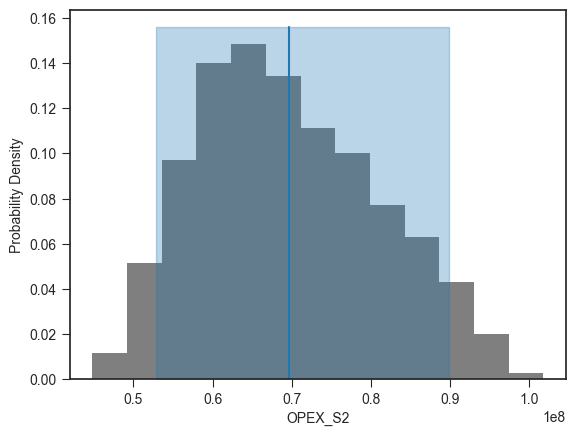

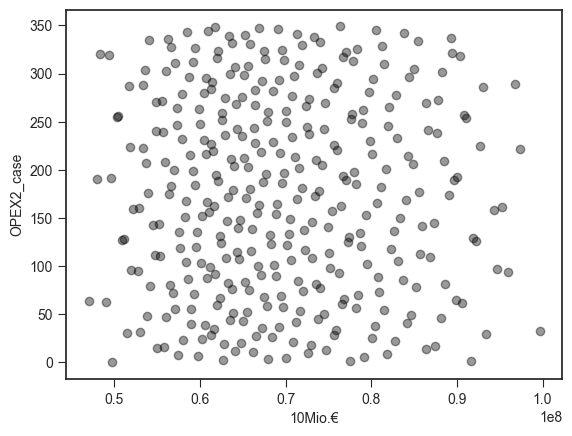

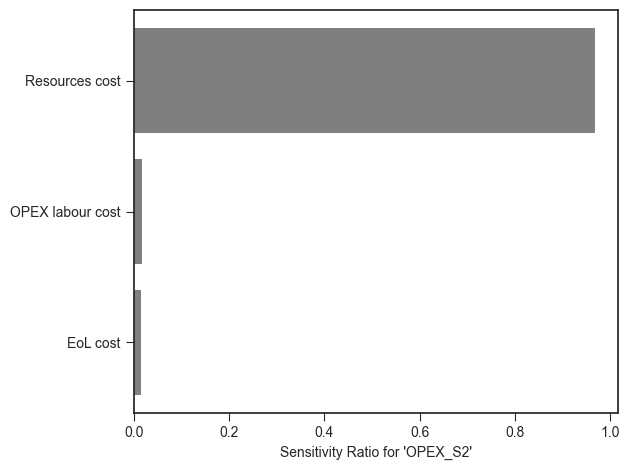

In [31]:
# Monaco OPEX S2 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(op_cost, op_labour, eol_cost):

       # run the opex simulation
       opr_cost = monte_opex(op_cost=op_cost, op_labour=op_labour, eol_cost=eol_cost)
       return (opr_cost, )


# Rename the y-axis in results
def preprocess(case):

    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    op_cost = case.invals['Resources cost'].val
    op_labour = case.invals['OPEX labour cost'].val
    eol_cost = case.invals['EoL cost'].val

    return (op_cost, op_labour, eol_cost)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, opr_cost):
    case.addOutVal(name='OPEX_S2', val=opr_cost)
    case.addOutVal(name='OPEX2_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='OPEX', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='Resources cost', dist=triang, distkwargs=triangular_from_stats(HISTORICAL_DISTRIBUTIONS['resources']['AWE_S2_resource_cost_20y']))
sim.addInVar(name='OPEX labour cost', dist=uniform, distkwargs={'loc': 45000, 'scale': 10000})
sim.addInVar(name='EoL cost', dist=uniform, distkwargs={'loc': 50000, 'scale': 2000})


# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# statistics for the dice sum
sim.outvars['OPEX_S2'].addVarStat('mean')
sim.outvars['OPEX_S2'].addVarStat('percentile', {'p':[0.05, 0.95]})
# Plots a histogram of the dice sum
mc.plot(sim.outvars['OPEX_S2'])
# Creates a scatter plot of the sum vs the roll
# number, showing randomness
mc.plot(sim.outvars['OPEX_S2'],
sim.outvars['OPEX2_case'])

# add Mio.€ in
plt.xlabel('10Mio.€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('OPEX_S2')
sim.outvars['OPEX_S2'].plotSensitivities()


In [32]:
# If:
#    resource cost is incl. taxes;
#    depreciation cost is considered;
#    there is any recoverable taxes was taking into account.
# Then: 
#    Tax impacts

# ---- Tax Impacts ----

# Feed needed data in
#kwargs={
#        'equity' : 0.25, 
#        'eq_rate_return': 0.07,
#        'debt': 0.75, 
#        'db_intrst_rate': 0.045,
#        'inflation_rate' : 0.01,
#        }

# Extract resource_cost from OPEX
#resource_cost = df_global['Total Resources Price'].tolist()

#print(resource_cost)

#tax_impct = tax_impact(resource_cost=0, tax_rate=0.3, int_on_debt=0.045, depreciation=0, **kwargs)
#print(f"Tax Impact: {tax_impct:.2f}")


In [33]:
# Life Cycle Cost S1 - Total cost of ownership (TCO)
# with OPEX_S1_mean

# TCO S1 (Mean) is calculated here based on all the parameters listed below
lcc_S1_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_mean, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_mean:.2f}")


Life Cycle Cost: 81111755.56


In [34]:
# Life Cycle Cost S1 - Total cost of ownership
# with OPEX_S1_higher

# TCO S1 (High) is calculated here based on all the parameters listed below
lcc_S1_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_high, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_high:.2f}")


Life Cycle Cost: 91523748.74


In [35]:
# Life Cycle Cost S1 - Total cost of ownership
# with OPEX_S1_lower

# TCO S1 (Low) is calculated here based on all the parameters listed below
lcc_S1_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S1_low, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S1_low:.2f}")


Life Cycle Cost: 70797037.81


In [36]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_mean

# TCO S2 (Mean) is calculated here based on all the parameters listed below
lcc_S2_mean = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_mean, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_mean:.2f}")


Life Cycle Cost: 59501354.08


In [37]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_higher

# TCO S2 (High) is calculated here based on all the parameters listed below
lcc_S2_high = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_high, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_high:.2f}")


Life Cycle Cost: 65250105.24


In [38]:
# Life Cycle Cost S2 - Total cost of ownership
# with OPEX_S2_lower

# TCO S2 (Low) is calculated here based on all the parameters listed below
lcc_S2_low = life_cycle_cost_of_h2(investment_cost=inv_cost, op_cost=op_cost_S2_low, tax_impact=0)
print(f"Life Cycle Cost: {lcc_S2_low:.2f}")


Life Cycle Cost: 53822903.57


Running 'Life Cycle Cost of H2_wos' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 667.19outvar/s]
Simulation complete! Runtime: 0:00:00.042529
Calculating sensitivity indices for 'TCO_S1'...
Calculating optimal hyperparameters Φ for 'TCO_S1' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'TCO_S1'">)

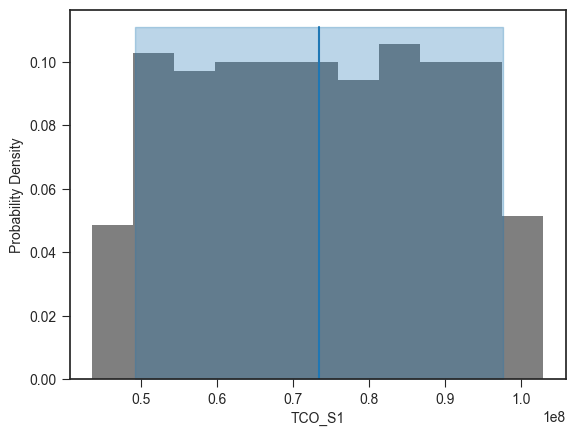

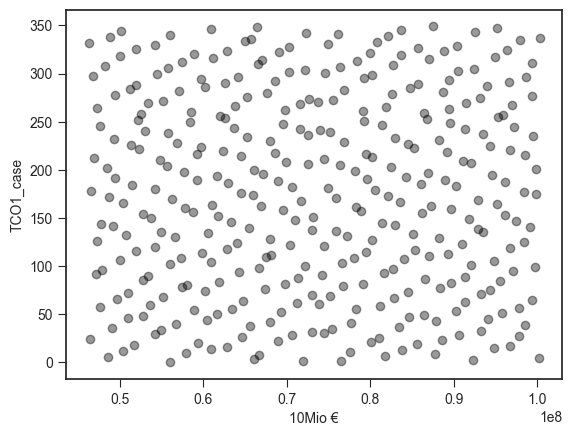

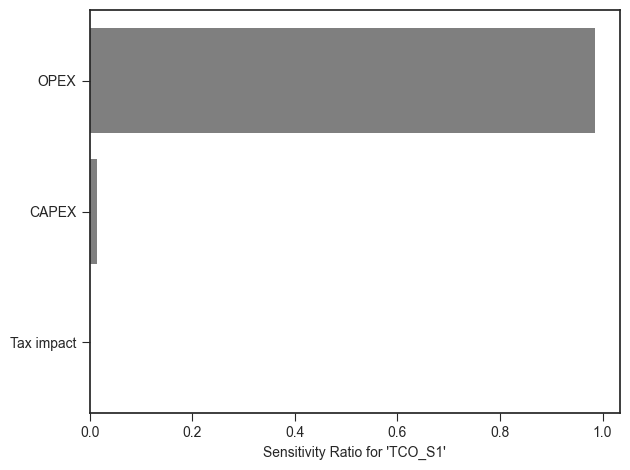

In [39]:
# Monaco TCO S1 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(investment_cost, opr_cost, tax_impact):

        # run the lcc simulation
        lcc_cost = monte_lcc(investment_cost=investment_cost, opr_cost=opr_cost, tax_impact=tax_impact)
        return (lcc_cost, )

 # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
def preprocess(case):
    investment_cost = case.invals['CAPEX'].val
    opr_cost = case.invals['OPEX'].val
    tax_impact = case. invals['Tax impact'].val

    return (investment_cost, opr_cost, tax_impact)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcc_cost):
    case.addOutVal(name='TCO_S1', val=lcc_cost)
    case.addOutVal(name='TCO1_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 # Arbitrary for this example
# Random seed for reproducibility
seed = 123456 # Recommended for repeatability
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='Life Cycle Cost of H2_wos', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='CAPEX', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_CAPEX']))  # propagated CAPEX range
sim.addInVar(name='OPEX', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_S1_OPEX']))  # full OPEX = resources + labour + EoL
sim.addInVar(name='Tax impact', dist=uniform, distkwargs={'loc': 0, 'scale': 1})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['TCO_S1'].addVarStat('mean')
sim.outvars['TCO_S1'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['TCO_S1'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['TCO_S1'],
sim.outvars['TCO1_case'])
plt.xlabel('10Mio €')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('TCO_S1')
sim.outvars['TCO_S1'].plotSensitivities()


Running 'Life Cycle Cost of H2_wos' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 3 input variables via the 'sobol_random' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 667.30outvar/s] 
Simulation complete! Runtime: 0:00:00.228087
Calculating sensitivity indices for 'TCO_S2'...
Calculating optimal hyperparameters Φ for 'TCO_S2' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'TCO_S2'">)

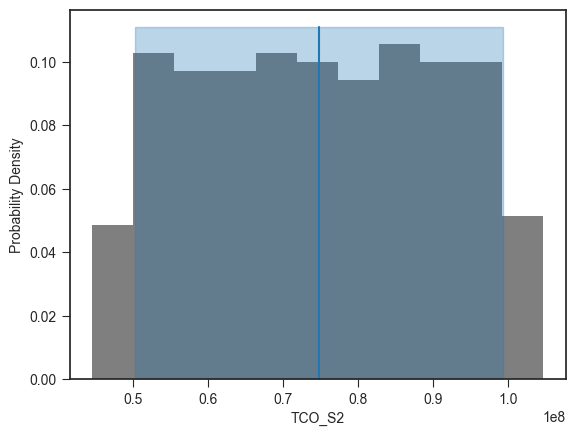

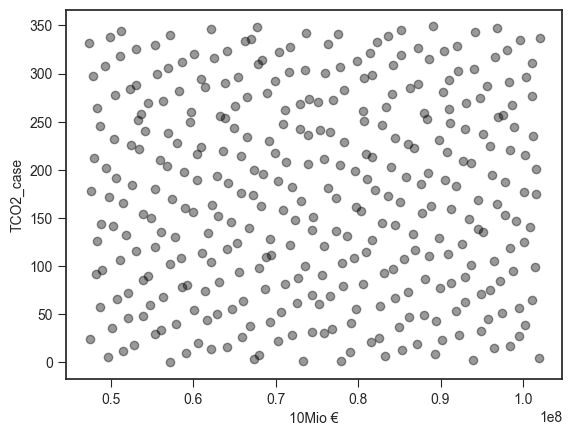

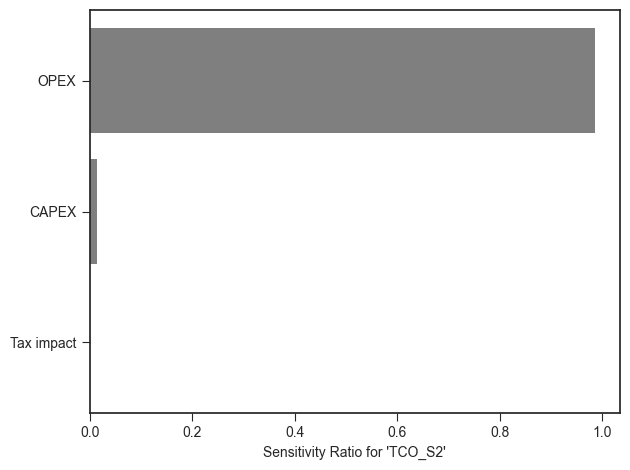

In [40]:
# Monaco TCO S2 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(investment_cost, opr_cost, tax_impact):

    # run the lcc simulation
    lcc_cost = monte_lcc(investment_cost=investment_cost, opr_cost=opr_cost, tax_impact=tax_impact)
    return (lcc_cost, )

# Rename the y-axis in results
def preprocess(case):
    
    # The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
    # Preprocess function for extracting usable variables from input dataframes
    investment_cost = case.invals['CAPEX'].val
    opr_cost = case.invals['OPEX'].val
    tax_impact = case. invals['Tax impact'].val

    return (investment_cost, opr_cost, tax_impact)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcc_cost):
    case.addOutVal(name='TCO_S2', val=lcc_cost)
    case.addOutVal(name='TCO2_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 # Arbitrary for this example
# Random seed for reproducibility
seed = 123456 # Recommended for repeatability
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='Life Cycle Cost of H2_wos', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol_random',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='CAPEX', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_CAPEX']))  # propagated CAPEX range
sim.addInVar(name='OPEX', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_S2_OPEX']))  # full OPEX = resources + labour + EoL
sim.addInVar(name='Tax impact', dist=uniform, distkwargs={'loc': 0, 'scale': 1})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['TCO_S2'].addVarStat('mean')
sim.outvars['TCO_S2'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['TCO_S2'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['TCO_S2'],
sim.outvars['TCO2_case'])
plt.xlabel('10Mio €')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('TCO_S2')
sim.outvars['TCO_S2'].plotSensitivities()


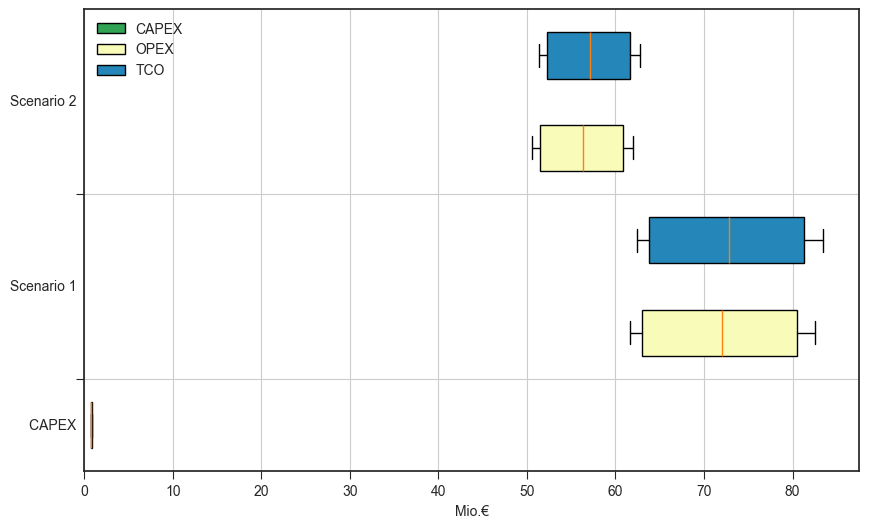

In [41]:
# Box plot - Results of CAPEX, OPEX and TCO - for manuscript

# Calcualted data from previous process
# p5 and p95 refer to the 5th and 95th percentiles respectively
# We use the p5 and p95 to plot a boxplot
# hard-coded plot summary values updated to new technology inputs
capex = {'min': 0.76, 'max': 0.86, 'median': 0.80, 'p5': 0.77, 'p95': 0.85}
opex_s1 = {'min': 61.6, 'max': 82.5, 'median': 72.0, 'p5': 63.0, 'p95': 80.5}
opex_s2 = {'min': 50.6, 'max': 62.0, 'median': 56.3, 'p5': 51.5, 'p95': 60.8}
tco_s1 = {'min': 62.4, 'max': 83.4, 'median': 72.8, 'p5': 63.8, 'p95': 81.3}
tco_s2 = {'min': 51.4, 'max': 62.8, 'median': 57.1, 'p5': 52.3, 'p95': 61.6}

# Draw the boxplot
plt.figure(figsize=(10, 6))

# Plotting the boxplot using the data defined above
bp = plt.boxplot(
    [[capex['min'], capex['p5'], capex['median'], capex['p95'], capex['max']],
    [opex_s1['min'], opex_s1['p5'], opex_s1['median'], opex_s1['p95'], opex_s1['max']],
    [tco_s1['min'], tco_s1['p5'], tco_s1['median'], tco_s1['p95'], tco_s1['max']],
    [opex_s2['min'], opex_s2['p5'], opex_s2['median'], opex_s2['p95'], opex_s2['max']],
    [tco_s2['min'], tco_s2['p5'], tco_s2['median'], tco_s2['p95'], tco_s2['max']]],
            labels=['CAPEX', 'OPEX S1', 'TCO S1', 'OPEX S2', 'TCO S2'], vert=False, patch_artist=True)

# Set color
colors = [(49/255, 163/255, 84/255), (249/255, 252/255, 185/255), (36/255, 134/255, 185/255), (249/255, 252/255, 185/255), (36/255, 134/255, 185/255)]
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color)

legend_elements = [Patch(facecolor=(49/255, 163/255, 84/255), edgecolor='black', label='CAPEX'),
                   Patch(facecolor=(249/255, 252/255, 185/255), edgecolor='black', label='OPEX'),
                   Patch(facecolor=(36/255, 134/255, 185/255), edgecolor='black', label='TCO'),]

plt.legend(handles=legend_elements, loc='upper left')

# Define x-axis
plt.xlabel('Mio.€')

# Set y-axis
plt.xlim(0) 

plt.yticks([1.5, 3.5], ['', ''])

# Set lengend
plt.text(0, 1, 'CAPEX  ', ha='right', va='center')
plt.text(0, 2.5, 'Scenario 1  ', ha='right', va='center')
plt.text(0, 4.5, 'Scenario 2  ', ha='right', va='center')

# Print plot
plt.grid(True)
plt.show()


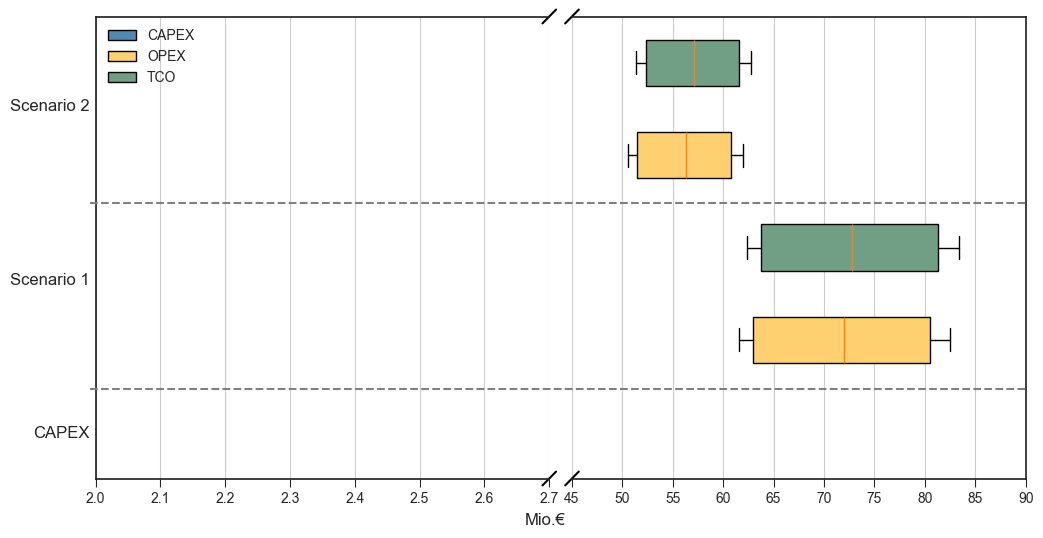

In [42]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Calculated data
# hard-coded plot summary values updated to new technology inputs
capex = {'min': 0.76, 'max': 0.86, 'median': 0.80, 'p5': 0.77, 'p95': 0.85}
opex_s1 = {'min': 61.6, 'max': 82.5, 'median': 72.0, 'p5': 63.0, 'p95': 80.5}
opex_s2 = {'min': 50.6, 'max': 62.0, 'median': 56.3, 'p5': 51.5, 'p95': 60.8}
tco_s1 = {'min': 62.4, 'max': 83.4, 'median': 72.8, 'p5': 63.8, 'p95': 81.3}
tco_s2 = {'min': 51.4, 'max': 62.8, 'median': 57.1, 'p5': 52.3, 'p95': 61.6}

# Create a figure and a grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
fig.subplots_adjust(wspace=0.05)

# Data for the box plots
data1 = [
    [capex['min'], capex['p5'], capex['median'], capex['p95'], capex['max']],
    [],
    [],
    [],
    []
]
data2 = [
    [],
    [opex_s1['min'], opex_s1['p5'], opex_s1['median'], opex_s1['p95'], opex_s1['max']],
    [tco_s1['min'], tco_s1['p5'], tco_s1['median'], tco_s1['p95'], tco_s1['max']],
    [opex_s2['min'], opex_s2['p5'], opex_s2['median'], opex_s2['p95'], opex_s2['max']],
    [tco_s2['min'], tco_s2['p5'], tco_s2['median'], tco_s2['p95'], tco_s2['max']]
]

# Plotting the box plots on both axes with colors
bp1 = ax1.boxplot(data1, vert=False, patch_artist=True)
bp2 = ax2.boxplot(data2, vert=False, patch_artist=True)

# Setting colors for the boxes in ax1
colors1 = [(80/255, 138/255, 178/255)] * 5  # CAPEX color for all boxes
for box, color in zip(bp1['boxes'], colors1):
    box.set(facecolor=color)

# Setting colors for the boxes in ax2
colors2 = [(255/255, 255/255, 255/255), (255/255, 208/255, 111/255), (113/255, 159/255, 133/255), (255/255, 208/255, 111/255), (113/255, 159/255, 133/255)]
for box, color in zip(bp2['boxes'], colors2):
    box.set(facecolor=color)

# Setting the limits for the x-axes
ax1.set_xlim(2, 2.7)
ax2.set_xlim(45, 90)

# Removing y-axis ticks and labels for both axes
ax1.yaxis.set_visible(False)
ax2.yaxis.set_visible(False)

# Removing the spines between the axes
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# Adding diagonal lines to indicate the broken axis
d = .015  # size of the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
ax2.plot((-d, +d), (-d, +d), **kwargs)  # top-left diagonal

# Adding horizontal lines between ax1 and ax2
line_y = 0.26  # y-coordinate for the line
line_color = 'gray'
line_style = '--'
fig.add_artist(plt.Line2D([0.12, 0.9], [line_y, line_y], transform=fig.transFigure, color=line_color, linestyle=line_style))

# Adding horizontal lines between ax2 and ax3
line_y = 0.57  # y-coordinate for the line
fig.add_artist(plt.Line2D([0.12, 0.9], [line_y, line_y], transform=fig.transFigure, color=line_color, linestyle=line_style))

# Set legend
legend_elements = [
    Patch(facecolor=(80/255, 138/255, 178/255), edgecolor='black', label='CAPEX'),
    Patch(facecolor=(255/255, 208/255, 111/255), edgecolor='black', label='OPEX'),
    Patch(facecolor=(113/255, 159/255, 133/255), edgecolor='black', label='TCO')
]
ax1.legend(handles=legend_elements, loc='upper left')

# Adding labels using fig.text() to position them relative to the figure
fig.text(0.5,0.04, 'Mio.€', ha='center', va='center', fontsize=12)

fig.text(0.12, 0.185, 'CAPEX', ha='right', va='center', fontsize=12)
fig.text(0.12, 0.44, 'Scenario 1', ha='right', va='center', fontsize=12)
fig.text(0.12, 0.73, 'Scenario 2', ha='right', va='center', fontsize=12)

# Show plot
ax1.grid(True)
ax2.grid(True)
plt.show()


In [43]:
fig.legend(handles=legend_elements, loc='upper left')


In [44]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_mean

# LCC S1 (Mean) is calculated here based on all the parameters listed below
kwargs = {
    'equity': 0.25,
    'eq_rate_return': 0.07,
    'debt': 0.75,
    'db_intrst_rate': 0.045,
    'inflation_rate': 0.01
}

lcoh_s1_mean = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S1_mean,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)

# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_mean:.2f}")


In [45]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_higher

# LCC S1 (High) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s1_high = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S1_high,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_high:.2f}")


In [46]:
# Levelized cost of hydrogen (LCOH) S1
# with LCC_S1_low

# LCC S1 (Low) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s1_low = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S1_low,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s1_low:.2f}")


In [47]:
# LCOH S2
# with LCC_S2_mean

# LCC S2 (Mean) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_mean = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S2_mean,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_mean:.2f}")


In [48]:
# LCOH S2
# with LCC_S2_higher

# LCC S2 (High) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_high = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S2_high,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_high:.2f}")


In [49]:
# LCOH S2
# with LCC_S2_lower

# LCC S2 (Low) is calculated here based on all the parameters listed below
kwargs={
        'equity' : 0.25, 
        'eq_rate_return': 0.07,
        'debt': 0.75, 
        'db_intrst_rate': 0.045,
        'inflation_rate' : 0.01
        }


lcoh_s2_low = levelized_cost_of_h2(
    life_cycle_cost_of_h2=lcc_S2_low,
    h2_production=19588000,  # AWE lifetime H2 production
    **kwargs
)
# If:
#       detailed data is needed
# Then:
#       print(f"Levelized Cost: {lcoh_s2_low:.2f}")


Running 'LCOH' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 7 input variables via the 'sobol' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 500.33outvar/s]
Simulation complete! Runtime: 0:00:00.052632
Calculating sensitivity indices for 'LCOH_S1'...
Calculating optimal hyperparameters Φ for 'LCOH_S1' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'LCOH_S1'">)

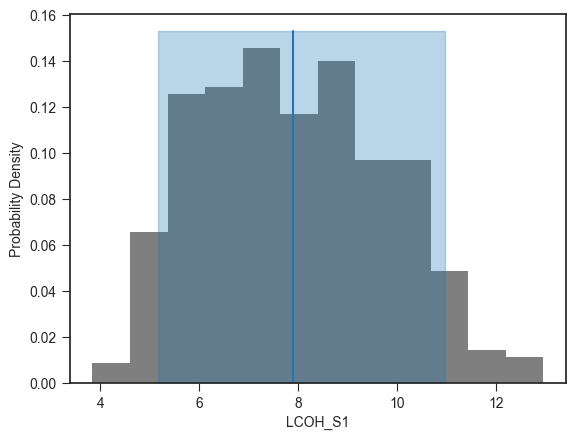

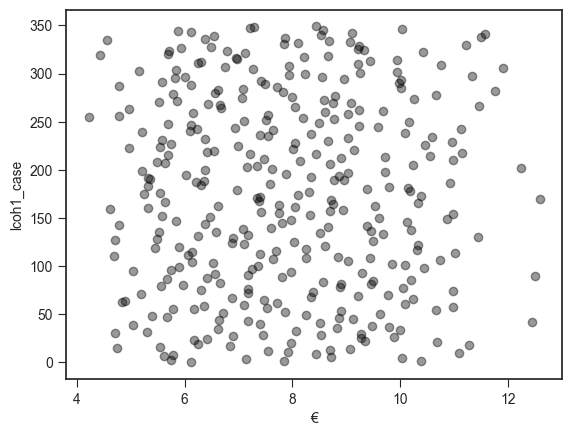

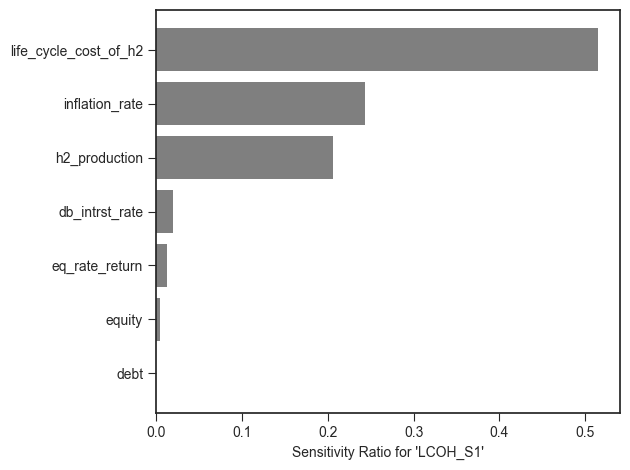

In [50]:
# Monaco LCOH S1 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate):
    kwargs={
        'inflation_rate' : inflation_rate,
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        }

    # run the lcoh simulation
    lcoh_cost = levelized_cost_of_h2(life_cycle_cost_of_h2=life_cycle_cost_of_h2, h2_production=h2_production, **kwargs)
    return (lcoh_cost, )

# The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
# Preprocess function for extracting usable variables from input dataframes
def preprocess(case):
    life_cycle_cost_of_h2 = case.invals['life_cycle_cost_of_h2'].val
    h2_production = case.invals['h2_production'].val
    equity = case.invals['equity'].val
    eq_rate_return = case.invals['eq_rate_return'].val
    debt = case.invals['debt'].val
    db_intrst_rate = case.invals['db_intrst_rate'].val
    inflation_rate = case.invals['inflation_rate'].val

    return (life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcoh_cost):
    case.addOutVal(name='LCOH_S1', val=lcoh_cost)
    case.addOutVal(name='lcoh1_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350
# Random seed for reproducibility
seed = 123456   # Recommanded for repeatability
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='LCOH', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='life_cycle_cost_of_h2', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_S1_TCO']))  # propagated from TCO S1
sim.addInVar(name='inflation_rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.05})
sim.addInVar(name='h2_production', dist=uniform, distkwargs={'loc': 18000000, 'scale': 4000000})  # AWE H2 production range 
sim.addInVar(name='equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.10})
sim.addInVar(name='eq_rate_return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='db_intrst_rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.005})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['LCOH_S1'].addVarStat('mean')
sim.outvars['LCOH_S1'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['LCOH_S1'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['LCOH_S1'],
sim.outvars['lcoh1_case'])
plt.xlabel('€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('LCOH_S1')
sim.outvars['LCOH_S1'].plotSensitivities()


Running 'LCOH' Monte Carlo simulation with 350/350 cases...
Drawing random samples for 7 input variables via the 'sobol' method...
Done
Generating cases...
Generating output variables: 100%|██████████| 2/2 [00:00<00:00, 666.03outvar/s]
Simulation complete! Runtime: 0:00:00.044773
Calculating sensitivity indices for 'LCOH_S2'...
Calculating optimal hyperparameters Φ for 'LCOH_S2' covariances...
Done calculating optimal hyperparameters.
Done calculating sensitivity indices.


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel="Sensitivity Ratio for 'LCOH_S2'">)

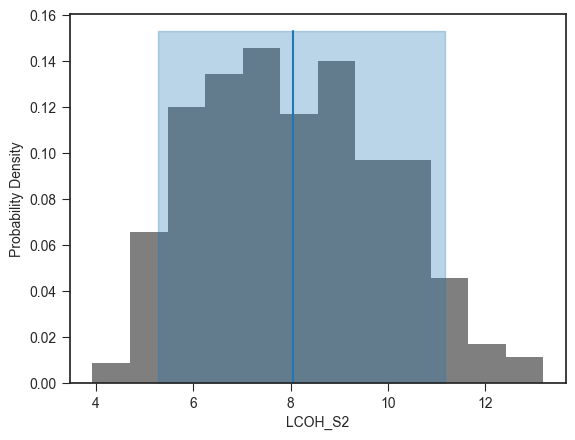

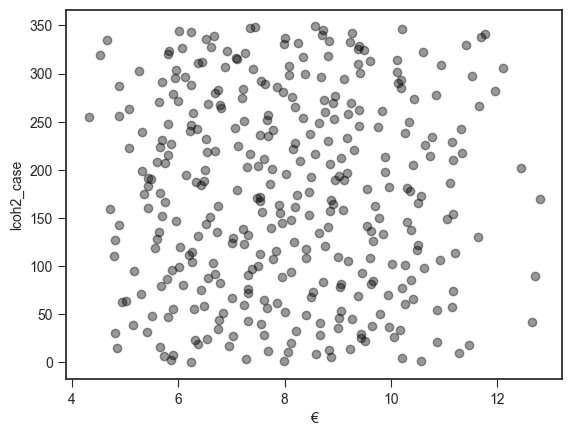

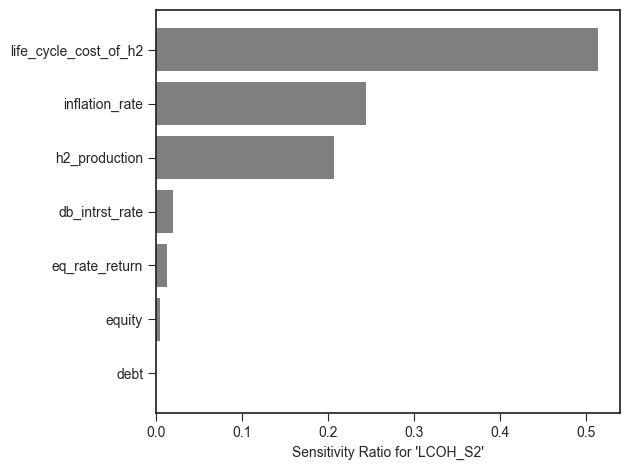

In [51]:
# Monaco LCOH S2 - Price range and sensitivity ratio

# Function for running the monte carlo simulation
def run(life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate):
    
    # variables used within the LCOH function (utils.py)
    kwargs={
        'inflation_rate' : inflation_rate,
        'equity' : equity,
        'eq_rate_return' : eq_rate_return,
        'debt' : debt,
        'db_intrst_rate' : db_intrst_rate,
        }
    
    # run the lcoh simulation
    lcoh_cost = levelized_cost_of_h2(life_cycle_cost_of_h2=life_cycle_cost_of_h2, h2_production=h2_production, **kwargs)
    return (lcoh_cost, )

# The 'preprocess' function grabs the random input values for each case and structures it with any other data in the format the 'run' function expects
# Preprocess function for extracting usable variables from input dataframes
def preprocess(case):
    life_cycle_cost_of_h2 = case.invals['life_cycle_cost_of_h2'].val
    h2_production = case.invals['h2_production'].val
    equity = case.invals['equity'].val
    eq_rate_return = case.invals['eq_rate_return'].val
    debt = case.invals['debt'].val
    db_intrst_rate = case.invals['db_intrst_rate'].val
    inflation_rate = case.invals['inflation_rate'].val

    return (life_cycle_cost_of_h2, h2_production, equity, eq_rate_return, debt, db_intrst_rate, inflation_rate)

# The 'postprocess' function takes the output from the 'run' function and saves off the outputs for each case
def postprocess(case, lcoh_cost):
    case.addOutVal(name='LCOH_S2', val=lcoh_cost)
    case.addOutVal(name='lcoh2_case', val=case.ncase)
    return None

# Argument list of functions used in simulator function
fcns = {'run' : run,
        'preprocess' : preprocess,
        'postprocess': postprocess}

# Number of iterations in the monte carlo simulation
n_invests = 350 
# Random seed for reproducibility
seed = 123456 
# Usage of monaco simulator with the SOBOL Random function
sim = mc.Sim(name='LCOH', ndraws=n_invests, 
            fcns=fcns, seed=seed, 
            samplemethod='sobol',
            singlethreaded=True,
            savecasedata=False,
            verbose=True, debug=True)

# Variables used in the simulation
# By manually change loc and scale can manage the uncertainty of the cost
sim.addInVar(name='life_cycle_cost_of_h2', dist=uniform, distkwargs=uniform_from_stats(MODEL_DISTRIBUTIONS['AWE_S2_TCO']))  # propagated from TCO S2
sim.addInVar(name='inflation_rate', dist=uniform, distkwargs={'loc': 0.01, 'scale': 0.05})
sim.addInVar(name='h2_production', dist=uniform, distkwargs={'loc': 18000000, 'scale': 4000000})  # AWE H2 production range 
sim.addInVar(name='equity', dist=uniform, distkwargs={'loc': 0.15, 'scale': 0.10})
sim.addInVar(name='eq_rate_return', dist=uniform, distkwargs={'loc': 0.05, 'scale': 0.01})
sim.addInVar(name='debt', dist=uniform, distkwargs={'loc': 0.75, 'scale': 0.01})
sim.addInVar(name='db_intrst_rate', dist=uniform, distkwargs={'loc': 0.045, 'scale': 0.005})

# Run the Simulation
sim.runSim()

# Calculate the mean and 5-95th percentile
# Statistics for the dice sum
sim.outvars['LCOH_S2'].addVarStat('mean')
sim.outvars['LCOH_S2'].addVarStat('percentile', {'p':[0.05, 0.95]})

# Plots a histogram of the dice sum
mc.plot(sim.outvars['LCOH_S2'])

# Creates a scatter plot of the sum vs the roll
# Number, showing randomness
mc.plot(sim.outvars['LCOH_S2'],
sim.outvars['lcoh2_case'])
plt.xlabel('€')

# Calculate the sensitivity of the dice sum to each of the input variables
sim.calcSensitivities('LCOH_S2')
sim.outvars['LCOH_S2'].plotSensitivities()


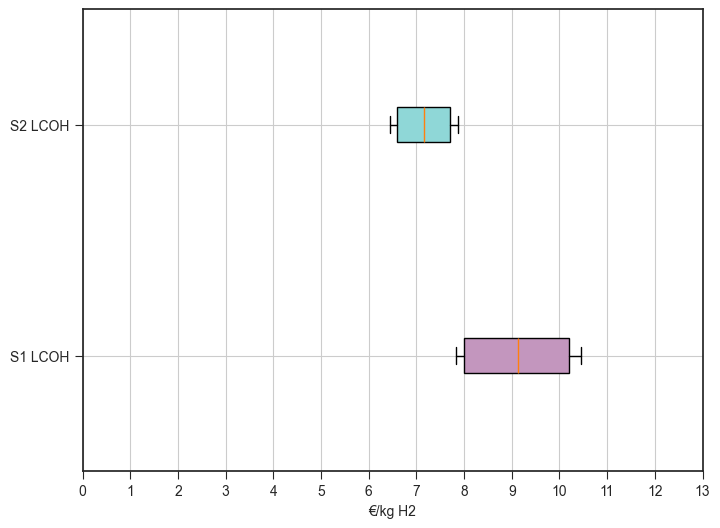

In [52]:
# Box plot - Results of LCOH in S1 and S2- for manuscript

# Calcualted data from previous process
# p5 and p95 refer to the 5th and 95th percentiles respectively
# we use the p5 and p95 to plot a boxplot
# hard-coded LCOH plot summary values updated
LCOH_s1 = {'min': 7.826, 'max': 10.443, 'median': 9.126, 'p5': 8.0, 'p95': 10.2}
LCOH_s2 = {'min': 6.438, 'max': 7.872, 'median': 7.152, 'p5': 6.6, 'p95': 7.7}

# Draw the boxplot
plt.figure(figsize=(8, 6))

# Plotting the boxplot using the data defined above
bp = plt.boxplot([[LCOH_s1['min'], LCOH_s1['p5'], LCOH_s1['median'], LCOH_s1['p95'], LCOH_s1['max']],
             [LCOH_s2['min'], LCOH_s2['p5'], LCOH_s2['median'], LCOH_s2['p95'], LCOH_s2['max']]],
            labels=['S1 LCOH', 'S2 LCOH'], vert=False, patch_artist=True)

# Set color
colors = [(195/255, 150/255, 190/255), (143/255, 215/255, 215/255)]
for box, color in zip(bp['boxes'], colors):
    box.set(facecolor=color)

plt.xlabel('€/kg H2')

# Manually define the x-axis
plt.xticks(range(0, 14))

# Print plot
plt.grid(True)
plt.show()


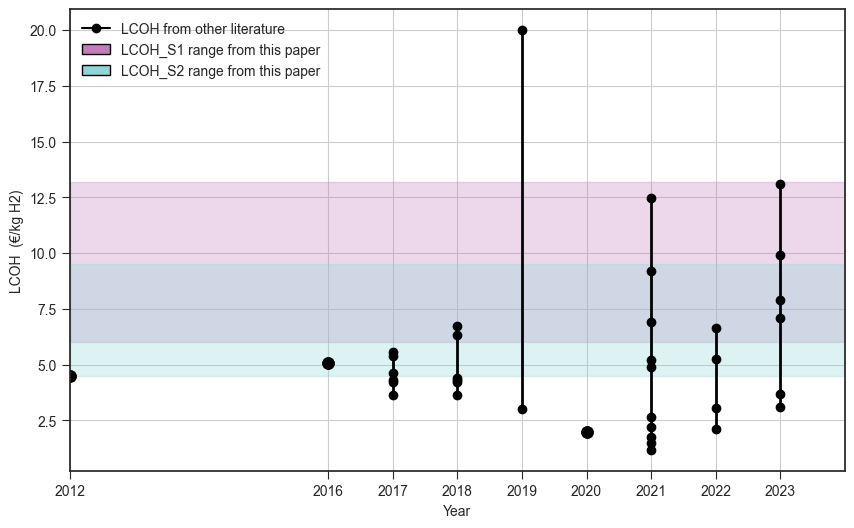

In [53]:
# Results validation - for manuscript

# Feed LCOH results from different literature
data = {
    "Year": [2012, 2016, 2017, 
             2018,
             2019,
             2020, 
             2021,
             2022, 2023],
    "LCOH Literature": [[4.49], [5.07], [3.64, 4.22, 4.31, 4.63, 5.38, 5.55], 
                        [3.64, 4.39, 4.22, 6.34, 4.31, 6.73],
                        [3, 20],
                        [2],
                        [9.2, 12.48, 6.90, 5.19, 1.16, 4.9, 1.47, 2.2, 1.75, 2.67],
                        [2.10, 5.24, 3.07, 6.63], [7.11, 7.88, 3.7, 9.9, 3.08, 13.12]],
}

# Extract data from above
years = data['Year']
lcoh_data = data['LCOH Literature']

# Plot price intervals using line plot
plt.figure(figsize=(10, 6))

for year, lcoh in zip(years, lcoh_data):
    if len(lcoh) == 1:
        plt.plot([year, year], [lcoh[0], lcoh[0]], color='black', linewidth=2, marker='o', markersize=8, label=f'{year} LCOH: {lcoh[0]}')
    else:
        ymin = min(lcoh)
        ymax = max(lcoh)
        plt.plot([year, year], [ymin, ymax], color='black', linewidth=2, label=f'{year} LCOH: {ymin} - {ymax}')
        plt.scatter([year] * len(lcoh), lcoh, color='black', zorder=5)

# Add our LCOH range
plt.fill_between(range(2012, 2025), 6, 13.2, color=(195/255, 125/255, 190/255), alpha=0.3)
plt.fill_between(range(2012, 2025), 4.5, 9.5, color=(143/255, 215/255, 215/255), alpha=0.3)

# Set the range of the x-axis
plt.xlim(2012, 2024)

# Set labels for x-axis and y-axis
plt.xlabel('Year')
plt.ylabel('LCOH  (€/kg H2)')

# Define legend elements
legend_elements = [Line2D([0], [0], marker='o', color='black', label='LCOH from other literature', markersize=6),
                   Patch(facecolor=(195/255, 125/255, 190/255), edgecolor='black', label='LCOH_S1 range from this paper'),
                   Patch(facecolor=(143/255, 215/255, 215/255), edgecolor='black', label='LCOH_S2 range from this paper')]

# Add legend
plt.legend(handles=legend_elements, loc='upper left')

# Show plot
plt.grid(True)

# Remove 2014 from x-axis ticks
plt.gca().set_xticks([2012, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

plt.show()
